In [1]:
import sys
print(sys.executable)

C:\Users\hankeun2\Desktop\brian_test\pram_env\Scripts\python.exe


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn import preprocessing as preprocessing
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms as T
from PIL import Image
from tqdm import tqdm, trange
from tensorboardX import SummaryWriter
from concurrent.futures import ThreadPoolExecutor
import time

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.figure import figaspect

import scipy.ndimage as ndimage
from scipy.optimize import curve_fit
from scipy.stats import multivariate_normal
import scipy.stats as stats
from scipy.ndimage import gaussian_filter, zoom
from absl import app, flags
from IPython import get_ipython
from IPython.display import clear_output
from skimage import io, morphology, filters, util

import gc 
from absl import app, flags
import datetime
import os
import sys
import cv2
from IPython.display import clear_output
from IPython import get_ipython
import random
import pandas as pd
import torch.multiprocessing as mp

if __name__ == '__main__':
    mp.set_start_method('spawn', force=True) # Add this line

# LOCA_PRAM — Downsampled variant

Identical to `LOCA_PRAM_main.ipynb` except for the `DOWNSCALE_FACTOR` config cell below, which downsamples the background image and shrinks the synthetic Gaussians (sigma + margin + window size) by the same factor. Set `DOWNSCALE_FACTOR = 1` to reproduce the original notebook.


In [3]:
# =====================================================================
# DOWNSCALE + PSF + MARKER CONFIG
# ---------------------------------------------------------------------
# DOWNSCALE_FACTOR=1 -> run at native resolution (current setup for the
# real training). Set >1 to also downsample the background image and
# shrink the synthetic Gaussians / window_size by the same factor.
#
# The PSF sigmas have been reduced to 1/4 of the original measured values
# (confirmed). The buffer used for placement rejection and inference-time
# p-map suppression is sigma-sized.
# =====================================================================
DOWNSCALE_FACTOR = 2

BASE_WINDOW_SIZE = (256, 256)
window_size = (BASE_WINDOW_SIZE[0] // DOWNSCALE_FACTOR,
               BASE_WINDOW_SIZE[1] // DOWNSCALE_FACTOR)

# PSF sigmas: 1/4 of the original measured values, then divided by
# DOWNSCALE_FACTOR for the actual training resolution.
# Direct measurements from new PSF analysis (n=146 after outlier removal):
#   sigma_x: 9.67 +/- 1.14, sigma_y: 7.85 +/- 1.37
# These replace the previous ~/4 manual reduction; no extra division needed.
BASE_SIGMA_X_LOC,   BASE_SIGMA_X_SCALE = 9.79, 1.32
BASE_SIGMA_Y_LOC,   BASE_SIGMA_Y_SCALE = 7.88, 1.38
BASE_SIGMA_MIN     = 2.5    # ~1/4 of mean sigma_y
BASE_MARGIN        = 12     # ~1.5 * mean sigma_x

SIGMA_X_LOC   = BASE_SIGMA_X_LOC   / DOWNSCALE_FACTOR
SIGMA_X_SCALE = BASE_SIGMA_X_SCALE / DOWNSCALE_FACTOR
SIGMA_Y_LOC   = BASE_SIGMA_Y_LOC   / DOWNSCALE_FACTOR
SIGMA_Y_SCALE = BASE_SIGMA_Y_SCALE / DOWNSCALE_FACTOR
SIGMA_MIN     = BASE_SIGMA_MIN     / DOWNSCALE_FACTOR
MARGIN        = max(1, int(round(BASE_MARGIN / DOWNSCALE_FACTOR)))

# Marker / banned-region config.
# Pixels <= MARKER_THRESHOLD are treated as marker (binary block) pixels.
# BUFFER_PX is sigma-sized: used both to dilate the marker mask before
# rejecting particle placements at training time AND to suppress the p-map
# inside the dilated marker region at inference time.
MARKER_THRESHOLD = 50
BUFFER_SIGMA_MULT = 5.0  # buffer radius = 5 * sigma; PSF body essentially zero beyond this
BUFFER_PX = int(round(BUFFER_SIGMA_MULT * max(SIGMA_X_LOC, SIGMA_Y_LOC)))


def compute_forbidden_mask(tile, buffer_px=None, threshold=None):
    """Return a boolean mask of the forbidden region for particle placement.

    forbidden = pixels within buffer_px of any pixel with intensity <= threshold.
    Uses a Euclidean distance transform so the cost is O(N) regardless of
    buffer size (binary_dilation with iterations=N is O(N * image)).

    Same mask used at inference to suppress predictions inside marker regions
    so training and inference distributions match.
    """
    if buffer_px is None:
        buffer_px = BUFFER_PX
    if threshold is None:
        threshold = MARKER_THRESHOLD
    marker = tile <= threshold
    if buffer_px <= 0 or not marker.any():
        return marker
    from scipy.ndimage import distance_transform_edt
    # distance from each pixel to nearest marker pixel; marker pixels are 0
    dist = distance_transform_edt(~marker)
    return dist <= buffer_px


def downsample_image(img, factor=None):
    """Average-pool downsample a 2-D image. factor=1 is a no-op."""
    if factor is None:
        factor = DOWNSCALE_FACTOR
    if factor == 1:
        return img
    import cv2
    h, w = img.shape[:2]
    return cv2.resize(img, (w // factor, h // factor), interpolation=cv2.INTER_AREA)


# ---- Input-image Gaussian smoothing ----
# Applied inside generate_simulation_image AFTER particles are added.
# Reduces pixel-noise std by ~sqrt(2*pi*sigma^2); SNR boost stacks with
# the downsample. sigma=0 disables. PSF radii here are 5-10 px so a small
# blur (sigma ~ 1) doesn't visibly broaden particles.
GAUSSIAN_BLUR_SIGMA = 0.0  # 0 disables; ~3% peak amplitude cost, ~2x noise reduction

def smooth_image(img, sigma=None):
    if sigma is None:
        sigma = GAUSSIAN_BLUR_SIGMA
    if sigma <= 0:
        return img
    from scipy.ndimage import gaussian_filter
    return gaussian_filter(img, sigma=sigma)


print(f"DOWNSCALE_FACTOR = {DOWNSCALE_FACTOR}")
print(f"window_size      = {window_size}")
print(f"sigma_x ~ N({SIGMA_X_LOC:.2f}, {SIGMA_X_SCALE:.2f})")
print(f"sigma_y ~ N({SIGMA_Y_LOC:.2f}, {SIGMA_Y_SCALE:.2f})")
print(f"placement margin = {MARGIN}, marker buffer = {BUFFER_PX} px ({BUFFER_SIGMA_MULT:.1f}*sigma)")
print(f"gaussian blur    = {GAUSSIAN_BLUR_SIGMA} px")


DOWNSCALE_FACTOR = 2
window_size      = (128, 128)
sigma_x ~ N(4.89, 0.66)
sigma_y ~ N(3.94, 0.69)
placement margin = 6, marker buffer = 24 px (5.0*sigma)
gaussian blur    = 0.0 px


## Prepare Background Tiles

In [4]:
from PIL import Image
Image.MAX_IMAGE_PIXELS = None

def standardize_image(image):
    """
    Standardize the pixel values of a 16-bit image so that the resulting image
    has a mean of 0 and a standard deviation of 1.

    Parameters:
    - image: A NumPy array representing the 16-bit input image.

    Returns:
    - A NumPy array of the standardized image.
    """
    image = image.astype(np.float32) / 255.
    mean = np.mean(image)
    std = np.std(image)
    standardized_image = (image - mean) / std
    print(f"mean: {mean}, std: {std}")
    return standardized_image

def shadow_remove(img):     
    """
    (Explanation needed)

    Parameters:
    - image: A NumPy array representing the 16-bit input image.

    Returns:
    - A NumPy array of the shadow removed image.
    """   
    dilated_img = morphology.dilation(img, morphology.square(11))
    bg_img = filters.median(dilated_img, morphology.disk(31))
    shadowremov = img - bg_img
    return shadowremov

def save_image(image):
    print(image.dtype)
    # Before saving, rescale and convert the processed image back to 16-bit
    final_img_16bit = rescale_to_16bit(image)
    cv2.imwrite('background_subtracted.png', final_img_16bit)

def rescale_to_16bit(image_float, target_range=(0, 65535)):
    """
    Rescales a floating-point image to the specified 16-bit range.

    Parameters:
    - image_float: A NumPy array of the image in floating-point format.
    - target_range: A tuple specifying the desired output range (min, max).

    Returns:
    - A NumPy array of the image rescaled to the 16-bit range.
    """
    min_val = np.min(image_float)
    max_val = np.max(image_float)
    scale = (target_range[1] - target_range[0]) / (max_val - min_val)
    image_16bit = (image_float - min_val) * scale + target_range[0]
    return image_16bit.astype(np.uint16)

def visualize_image(images, labels, backgrounds, image_index=0, figsize=(2000, 800)):
    """
    Visualize the images. 
    - image:            Number of training images generated. 
                        (num_imgs, 1, img_width, img_height)
    - background:       Previously generated "bg_tiles" is used. 
                        (num_imgs, 1, img_width, img_height)
    - labels:           One-hot representation of the center of the PSFs. 
                        (num_imgs, 1, img_width, img_height)
    - labels_density:   When "labels" are the one-hot representation, "label_density" has pixel value of 100 followed by smoothing with gaussian filter 
                        (num_imgs, 1, img_width, img_height)
    - image_index:      For sanity check, a single image from the training set is displayed. 
                        (int)
    - figsize:          Size of the figure. 
                        ex) (1000, 1000)
                        
    Returns:
    - None
    """   

    if labels.ndim == 3:
        labels = labels.unsqueeze(0)
        backgrounds = backgrounds.unsqueeze(0)
    if images.ndim == 3:
        images = images.unsqueeze(0)
    
    print(f"image index: {image_index}")
    num_imgs, img_channel, img_size_x, img_size_y = images.shape
    px = 1/plt.rcParams['figure.dpi'] 
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(figsize[0]*px, figsize[1]*px))

    for i, ax in enumerate(axes.flatten()):
        D = np.squeeze(images[image_index, ...] )
        if not i % 4:
            GT = np.squeeze(labels[image_index, 2, ...] > 0)
            BG = np.squeeze(backgrounds[image_index, 0, ...])
            a = ax.imshow(D, origin='lower', cmap='gray')
            ax.set_title('Input Image')
        if i%4 == 1:
            a = ax.imshow(BG, origin='lower', cmap='gray')
            ax.set_title('Input Background')
        if i%4 == 2:
            a = ax.imshow(GT, origin='lower', cmap='gray')
            ax.set_title('Ground Truth Center')
            
        fig.colorbar(a, ax=ax, fraction=0.046)
        ax.set_xlim([0, img_size_x])
        ax.set_ylim([img_size_y, 0])

    plt.tight_layout()
    plt.show()
    
def prepare_background_tiles(bg_image_path, window_size):
    """
    Load a synthetic background image and tile it.
    
    Parameters:
    - bg_image_path: Path to the synthetic background image
    - window_size: Tuple (height, width) for each tile
    
    Returns:
    - bg_tiles: NumPy array of shape (num_tiles, height, width)
    """
    # Load image
    bg_image = np.asarray(Image.open(bg_image_path).convert('L')).astype(np.float32)
    if DOWNSCALE_FACTOR != 1:
        bg_image = downsample_image(bg_image)
        print(f"Downsampled background by {DOWNSCALE_FACTOR}x: {bg_image.shape}")
    print(f"Loaded background: {bg_image.shape}, range: [{bg_image.min():.1f}, {bg_image.max():.1f}]")
    
    # Normalize to 0-1
    bg_image = (bg_image - bg_image.min()) / (bg_image.max() - bg_image.min())
    
    bg_height, bg_width = bg_image.shape
    bg_tiles = []
    
    # Tile the image
    for i in range(int(bg_height / window_size[0])):
        for j in range(int(bg_width / window_size[1])):
            bg_tile = bg_image[i*window_size[0] : i*window_size[0] + window_size[0], 
                               j*window_size[1] : j*window_size[1] + window_size[1]]
            bg_tiles.append(bg_tile)
    
    bg_tiles = np.asarray(bg_tiles)
    print(f"Generated {len(bg_tiles)} tiles of size {window_size}")
    
    # Visualization
    index = 0
    fig, subplots = plt.subplots(1, 2, figsize=(16, 6))
    subplots[0].set_title("Synthetic Background")
    subplot_0 = subplots[0].imshow(bg_image, cmap='gray')
    rect = patches.Rectangle((window_size[1] * (index % int(bg_width / window_size[1])), 
                               window_size[0] * (index // int(bg_width / window_size[1]))), 
                              window_size[1], window_size[0], linewidth=2, linestyle='--', 
                              edgecolor='r', facecolor='none')
    subplots[0].add_patch(rect)
    fig.colorbar(subplot_0, ax=subplots[0], fraction=0.03)
    subplot_1 = subplots[1].imshow(bg_tiles[index].squeeze(), cmap='gray')
    subplots[1].set_title(f"Tile #{index}")
    fig.colorbar(subplot_1, ax=subplots[1], fraction=0.05)
    plt.tight_layout()
    plt.show()
    
    return bg_tiles

if __name__ == '__main__':
    # NOTE: original single-image loader disabled; the real loader is
    # in the next code cell (multi-FOV from the demo_0001 folder).
    pass


## Authentic Image for Testing
### Sanity Check

In [5]:
# =====================================================================
# Multi-FOV background loader
# ---------------------------------------------------------------------
# Walks the BG_FOLDER, splits FOVs into train / eval, takes the RED
# channel of each JPG, sub-tiles each FOV at window_size, drops tiles
# that are essentially 100% marker (no usable signal). Produces two
# pools: bg_tiles_train and bg_tiles_eval. bg_tiles is aliased to the
# train pool for backward compatibility with the visualization cells.
# =====================================================================
import glob
import os

BG_FOLDER = 'demo_0001'
TRAIN_FOV_COUNT = 100
SPLIT_SEED = 42
# Min fraction of pixels that are placeable AFTER marker dilation + edge margin.
# Direct gate on what generate_simulation_image can actually use; replaces the
# raw marker_frac threshold which underestimated the impact of the sigma buffer
# at small tile sizes (a 65% marker tile can have 0% placeable area at 128x128).
MIN_PLACEABLE_FRAC = 0.05


def load_fov_red(path):
    """Open a JPG FOV and return the red channel as float32 (0-255 range)."""
    arr = np.asarray(Image.open(path))
    if arr.ndim == 3:
        arr = arr[:, :, 0]
    arr = arr.astype(np.float32)
    if DOWNSCALE_FACTOR != 1:
        arr = downsample_image(arr)
    return arr


def _placeable_frac(tile):
    """Fraction of pixels that pass marker dilation + edge margin — i.e. that
    generate_simulation_image could actually place a particle on."""
    forbidden = compute_forbidden_mask(tile)
    if MARGIN > 0:
        forbidden[:MARGIN, :] = True
        forbidden[-MARGIN:, :] = True
        forbidden[:, :MARGIN] = True
        forbidden[:, -MARGIN:] = True
    return float((~forbidden).mean())


def tile_fovs(fov_paths, window_size, label=""):
    tiles = []
    n_dropped = 0
    for p in fov_paths:
        img = load_fov_red(p)
        h, w = img.shape
        for i in range(h // window_size[0]):
            for j in range(w // window_size[1]):
                tile = img[i*window_size[0]:(i+1)*window_size[0],
                           j*window_size[1]:(j+1)*window_size[1]]
                if _placeable_frac(tile) < MIN_PLACEABLE_FRAC:
                    n_dropped += 1
                    continue
                # Blur applied AFTER the placeable filter (which needs raw
                # values for the marker threshold) but BEFORE storing — so
                # bg_tiles holds smoothed tiles and bg-head input/target stay
                # consistent. No-op if sigma=0.
                tile = smooth_image(tile)
                tiles.append(tile)
    arr = np.asarray(tiles)
    print(f"  {label}: {len(fov_paths)} FOVs -> {len(arr)} tiles "
          f"(dropped {n_dropped} with placeable_frac < {MIN_PLACEABLE_FRAC:.0%})")
    return arr


all_fovs = sorted(glob.glob(os.path.join(BG_FOLDER, '*.jpg')))
assert len(all_fovs) > TRAIN_FOV_COUNT, \
    f"need > {TRAIN_FOV_COUNT} FOVs in {BG_FOLDER}, found {len(all_fovs)}"

rng = np.random.RandomState(SPLIT_SEED)
perm = rng.permutation(len(all_fovs))
train_fovs = [all_fovs[i] for i in perm[:TRAIN_FOV_COUNT]]
eval_fovs  = [all_fovs[i] for i in perm[TRAIN_FOV_COUNT:]]
print(f"Loaded {len(all_fovs)} FOVs from {BG_FOLDER}")
print(f"  train: {len(train_fovs)} FOVs")
print(f"  eval : {len(eval_fovs)} FOVs (held out)")

bg_tiles_train = tile_fovs(train_fovs, window_size, label="train")
bg_tiles_eval  = tile_fovs(eval_fovs,  window_size, label="eval ")

# Alias for backward compatibility with later visualization cells.
bg_tiles = bg_tiles_train

print(f"Tile value range (train): "
      f"[{bg_tiles_train.min():.1f}, {bg_tiles_train.max():.1f}]")


Loaded 127 FOVs from demo_0001
  train: 100 FOVs
  eval : 27 FOVs (held out)
  train: 100 FOVs -> 15895 tiles (dropped 605 with placeable_frac < 5%)
  eval : 27 FOVs -> 4295 tiles (dropped 160 with placeable_frac < 5%)
Tile value range (train): [0.0, 255.0]


## Training Data Generation

In [6]:
def generate_simulation_image(img_size, bg_tiles, num_gaus_low=1, num_gaus_high=12, labels_channel=3):
    """
    Generates a simulated image with synthetic PSF particles on a real
    background tile (sampled at random from bg_tiles).

    Compared to the original, this version:
      * computes a forbidden mask (markers + sigma buffer + edge margin) from
        the chosen bg tile, and rejects particle placements that fall inside it
      * scales the particle count by the active (non-forbidden) fraction so
        density per available area stays constant across tiles
      * still leaves the markers themselves visible in the input image — the
        bg head is expected to reconstruct them; the p head learns to ignore
        them via the absence of GT labels inside the forbidden region.

    OPTIMIZED: separable 1D Gaussians via np.outer (no scipy multivariate).
    """
    bg_idx = np.random.randint(0, len(bg_tiles))
    gauss_base = bg_tiles[bg_idx].copy()
    bg_clean   = bg_tiles[bg_idx]  # reference (no particles) for downstream

    # ---- Forbidden mask: markers dilated by BUFFER_PX, plus edge margin ----
    forbidden = compute_forbidden_mask(bg_clean)
    if MARGIN > 0:
        forbidden[:MARGIN, :] = True
        forbidden[-MARGIN:, :] = True
        forbidden[:, :MARGIN] = True
        forbidden[:, -MARGIN:] = True

    placeable_ys, placeable_xs = np.where(~forbidden)
    active_frac = placeable_ys.size / forbidden.size

    # Pre-compute coordinate vectors
    x_vec = np.arange(img_size[1])
    y_vec = np.arange(img_size[0])

    labels = np.zeros((labels_channel, img_size[0], img_size[1]))

    # ---- Density-aware particle count ----
    # Stochastic rounding: the fractional remainder is resolved by a
    # Bernoulli draw instead of rounded away. This preserves the correct
    # expected count even when nominal_count * active_frac < 0.5 (which
    # would otherwise always round down to 0).
    nominal_count = np.random.randint(num_gaus_low, num_gaus_high)
    scaled = nominal_count * active_frac
    n_floor = int(scaled)
    n_to_place = n_floor + (1 if np.random.random() < (scaled - n_floor) else 0)

    if placeable_ys.size == 0:
        n_to_place = 0  # nothing placeable

    MAX_ATTEMPTS = 50
    for _ in range(n_to_place):
        # 1. Sample center from placeable pixels (one rejection-free pick from
        #    the pre-computed pool; sub-pixel jitter is added).
        k = np.random.randint(0, placeable_ys.size)
        iy_base = placeable_ys[k]
        ix_base = placeable_xs[k]
        x_c = ix_base + np.random.uniform(0, 1)
        y_c = iy_base + np.random.uniform(0, 1)

        # 2. Sample amplitude (unchanged)
        # Amplitude from new PSF measurement: mean=9.13, std=3.31 (wider than old 10+/-1.544)
        # Wider distribution includes more dim (hard) and bright (easy) particles - closer to reality.
        amplitude = np.random.normal(loc=31.22, scale=11.15)
        if amplitude < 1.0:
            amplitude = 1.0

        # 3. Sample sigma (PSF-reduced + downscaled values)
        raw_sigma_x = np.random.normal(loc=SIGMA_X_LOC, scale=SIGMA_X_SCALE)
        raw_sigma_y = np.random.normal(loc=SIGMA_Y_LOC, scale=SIGMA_Y_SCALE)
        sigma_x = max(SIGMA_MIN, raw_sigma_x)
        sigma_y = max(SIGMA_MIN, raw_sigma_y)

        # 4. Render separable Gaussian
        g_x = np.exp(-((x_vec - x_c) ** 2) / (2 * sigma_x ** 2))
        g_y = np.exp(-((y_vec - y_c) ** 2) / (2 * sigma_y ** 2))
        particle = np.outer(g_y, g_x) * amplitude

        gauss_base -= particle

        # 5. Update labels (one-hot at the integer center)
        ix, iy = int(x_c), int(y_c)
        if 0 <= ix < img_size[1] and 0 <= iy < img_size[0]:
            labels[0, iy, ix] = x_c - ix
            labels[1, iy, ix] = y_c - iy
            labels[2, iy, ix] = 1.0

    gauss_base = np.clip(gauss_base, 0, 65535)
    # Smoothing is now applied to bg_tiles at load time, so both the
    # composite and bg_clean here are already-smoothed and consistent.
    return gauss_base, labels, bg_clean


In [7]:
tile = bg_tiles[0]
print(f"Tile mean: {tile.mean():.1f}")
print(f"Tile std:  {tile.std():.1f}")
print(f"Tile local std (32x32 patches):")
for y in range(0, 512, 128):
    for x in range(0, 512, 128):
        patch = tile[y:y+32, x:x+32]
        print(f"  ({y},{x}): std={patch.std():.2f}")
print(f"Particle amplitude: ~10")
print(f"Noise level: ~2.7")

Tile mean: 244.7
Tile std:  6.9
Tile local std (32x32 patches):
  (0,0): std=3.57
  (0,128): std=nan
  (0,256): std=nan
  (0,384): std=nan
  (128,0): std=nan
  (128,128): std=nan
  (128,256): std=nan
  (128,384): std=nan
  (256,0): std=nan
  (256,128): std=nan
  (256,256): std=nan
  (256,384): std=nan
  (384,0): std=nan
  (384,128): std=nan
  (384,256): std=nan
  (384,384): std=nan
Particle amplitude: ~10
Noise level: ~2.7


C:\Users\hankeun2\Desktop\brian_test\pram_env\Lib\site-packages\numpy\_core\_methods.py:222: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
C:\Users\hankeun2\Desktop\brian_test\pram_env\Lib\site-packages\numpy\_core\_methods.py:180: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
C:\Users\hankeun2\Desktop\brian_test\pram_env\Lib\site-packages\numpy\_core\_methods.py:214: RuntimeWarning: invalid value encountered in divide
  ret = ret.dtype.type(ret / rcount)


### Asynchronous Dataset Loading

Visual comparison: Background vs Background+Particles


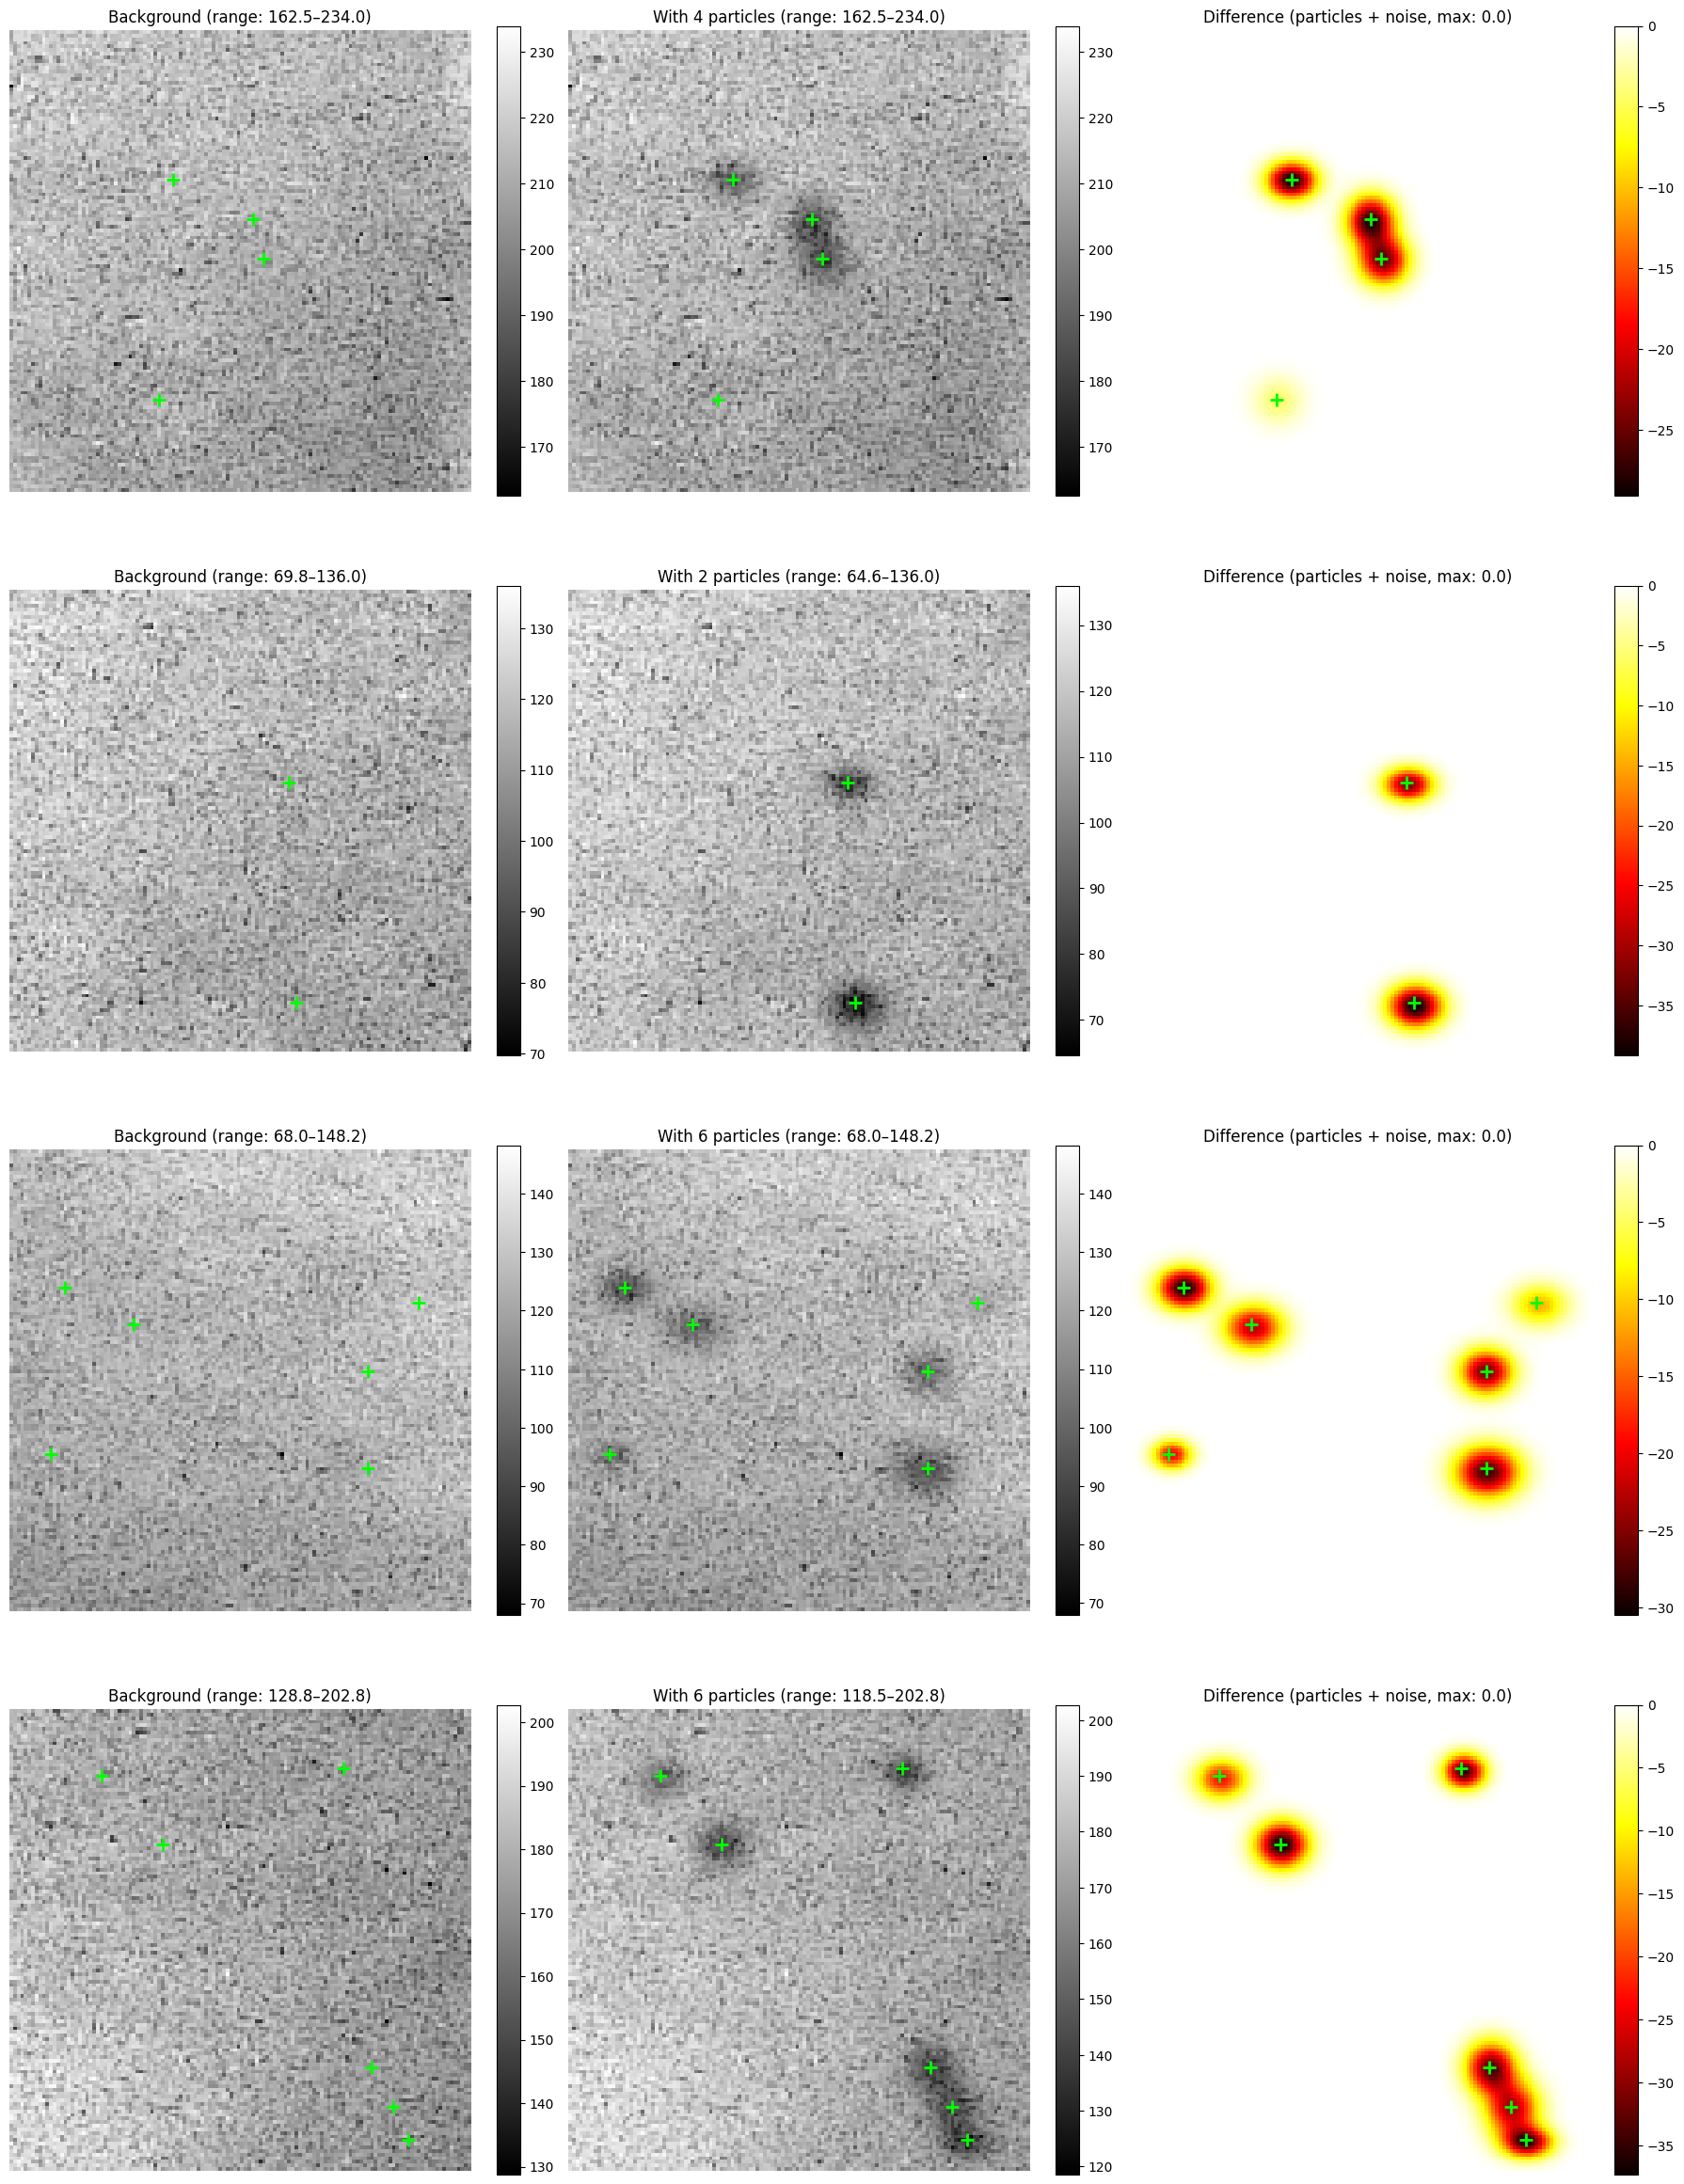

In [8]:
class GaussianDataset(Dataset):
    def __init__(self, num_batches, bg_tiles, img_size=(512, 512), transform=None):
        self.transform = transform
        self.num_batches = num_batches
        self.bg_tiles = bg_tiles
        self.img_size = img_size
        self.labels_channel = 3
        
        # --- DYNAMIC DENSITY CALCULATION ---
        # Goal: Keep particle-to-image coverage ratio consistent with the original version (20% coverage)
        
        # 1. Reference (Original Setup)
        # 50 particles (radius ~3px) in 84x84
        ref_coverage_ratio = 0.20 
        
        # 2. New Setup (Current Config)
        new_window_area = self.img_size[0] * self.img_size[1]
        
        # Using the Mean Sigmas you provided earlier
        new_sigma_x = 47.67
        new_sigma_y = 30.71
        
        
        # PSF area shrank ~16x (sigma 4x smaller); bumped 4x to 0-23 so we
        # actually get overlapping particles for the model to learn that case.
        self.num_gaus_low = 0
        self.num_gaus_high = 10
        
        # print(f"Density Calculation for {img_size}:")
        # print(f"  - Particle Dimensions: ~{int(new_sigma_x*4)}x{int(new_sigma_y*4)} pixels")
        # print(f"  - Max Particles set to: {self.num_gaus_high}")

    def __len__(self):
        return self.num_batches

    def __getitem__(self, idx):
        # We call the generate function we defined in the previous cell
        image, labels, bg_image = generate_simulation_image(
            img_size=self.img_size, 
            bg_tiles=self.bg_tiles, 
            num_gaus_low=self.num_gaus_low, 
            num_gaus_high=self.num_gaus_high,
            labels_channel=self.labels_channel
        )
        
        # Standardize / Normalize -- ignore marker pixels so one black
        # block doesn't dominate the mean/std and crush contrast.
        valid = bg_image > MARKER_THRESHOLD
        if valid.any():
            m = image[valid].mean()
            s = image[valid].std()
        else:
            m = image.mean()
            s = image.std()
        if s == 0:
            s = 1
        image = (image - m) / s
        
        # Normalize bg_image with the SAME (m, s) as input so the bg head
        # supervises in the same normalized space.
        bg_image = (bg_image - m) / s

        # Convert to Tensor
        image = torch.from_numpy(image).float().unsqueeze(0) # (1, H, W)
        labels = torch.from_numpy(labels).float()            # (3, H, W)
        bg_image = torch.from_numpy(bg_image).float().unsqueeze(0)
        
        # Apply transforms if they exist
        if self.transform:
            image = self.transform(image)
            
        return image, labels, bg_image

# Asynchronous data loading function for batches
def async_load_batch(data_loader):
    """Load batches asynchronously using a thread pool."""
    with ThreadPoolExecutor(max_workers=8) as executor:
        futures = [executor.submit(load_batch, batch) for batch in data_loader]
        for future in futures:
            yield future.result()

def load_batch(batch):
    """Simulate batch loading (you can customize this to fit your process)."""
    time.sleep(0.1)  # Simulate a delay (remove or adjust depending on your loading time)
    return batch

# Sanity Check: Visualizing asynchronously generated data
def sanity_check(images):
    plt.figure(figsize=(8, 8))
    # Loop over generated data for visualization and checking
    for i in range(images.shape[0]):
        if i < 4 :
            plt.subplot(2, 2, i + 1)
            plt.imshow(images[i].squeeze(), cmap='gray')
            plt.colorbar()
            plt.title(f"Generated Image {i+1}")
            plt.axis('off')
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    # Generate a few images and show background vs background+particles side by side
    print("Visual comparison: Background vs Background+Particles")
    
    num_examples = 4
    fig, axes = plt.subplots(num_examples, 3, figsize=(18, 6 * num_examples))
    
    for i in range(num_examples):
        image, labels, bg_image = generate_simulation_image(
            img_size=window_size,
            bg_tiles=bg_tiles,
            num_gaus_low=0,
            num_gaus_high=10,
            labels_channel=3
        )
        
        diff = image - bg_image  # isolates particles + noise
        
        # A. Background only
        axes[i, 0].imshow(bg_image, cmap='gray')
        axes[i, 0].set_title(f'Background (range: {bg_image.min():.1f}–{bg_image.max():.1f})')
        fig.colorbar(axes[i, 0].images[0], ax=axes[i, 0], fraction=0.046)
        
        # B. Background + particles
        axes[i, 1].imshow(image, cmap='gray')
        num_particles = int(labels[2].sum())
        axes[i, 1].set_title(f'With {num_particles} particles (range: {image.min():.1f}–{image.max():.1f})')
        fig.colorbar(axes[i, 1].images[0], ax=axes[i, 1], fraction=0.046)
        
        # C. Difference (particles + noise only)
        im = axes[i, 2].imshow(diff, cmap='hot')
        axes[i, 2].set_title(f'Difference (particles + noise, max: {diff.max():.1f})')
        fig.colorbar(im, ax=axes[i, 2], fraction=0.046)
        
        # Mark true centers on all panels
        ys, xs = np.where(labels[2] > 0)
        for ax in axes[i]:
            ax.scatter(xs, ys, color='lime', marker='+', s=100, linewidths=2)
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

Heaviest usable tile: idx 8263, marker frac = 52.36%
Active frac (after marker dilation + edge margin): 8.31%


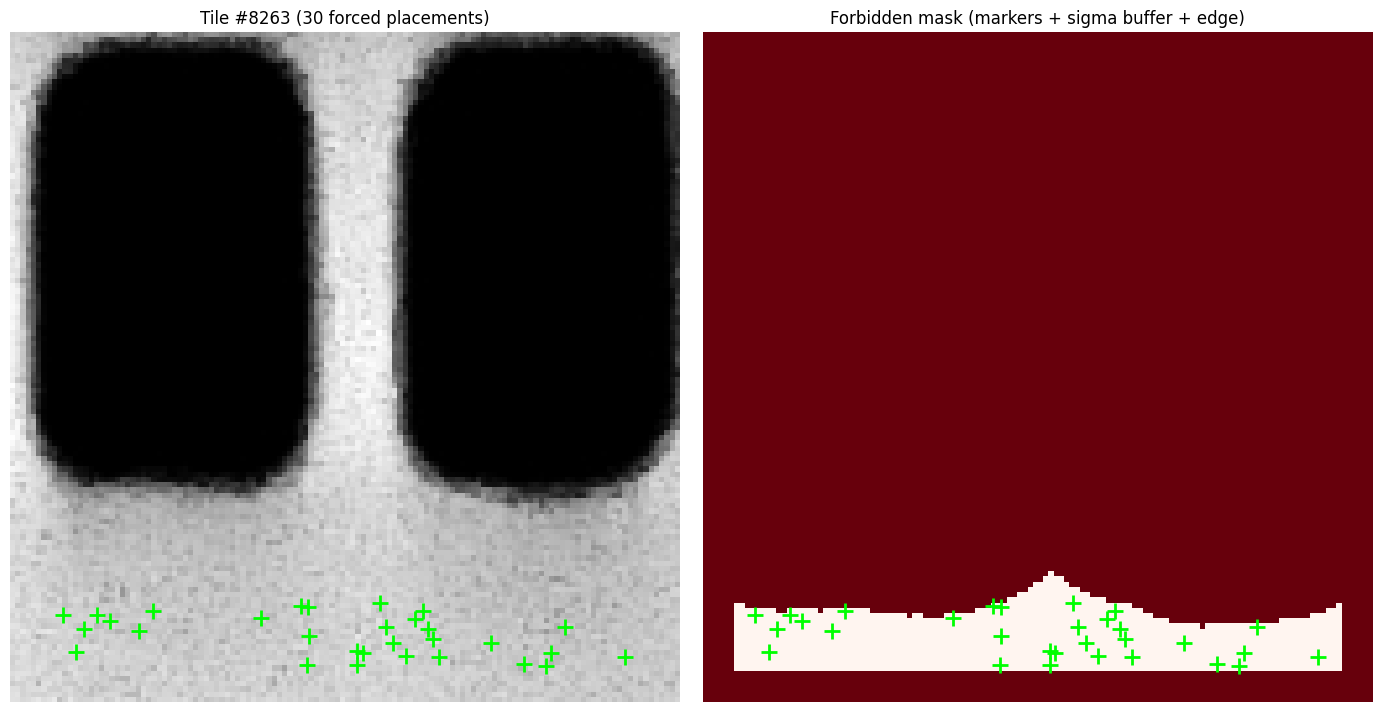

Sampled centers inside forbidden mask: 0 / 30 (should be 0)


In [9]:
# =====================================================================
# Marker-avoidance diagnostic
# ---------------------------------------------------------------------
# Picks the tile with the heaviest marker coverage, draws the forbidden
# mask (markers + sigma buffer), then places 30 particles *unconditionally*
# (density scaling bypassed). Every green cross should sit in the
# non-red region. Run once to confirm rejection sampling is healthy;
# delete afterwards.
# =====================================================================
if __name__ == '__main__':
    # Walk marker-heaviest tiles in order; pick the first one that still has
    # placeable area after marker dilation + edge margin. At small tile sizes
    # the very heaviest tile may have zero placeable pixels (the buffer dilates
    # the marker mask to cover everything), which would crash np.random.randint.
    marker_fracs = [(i, (t <= MARKER_THRESHOLD).mean()) for i, t in enumerate(bg_tiles)]
    marker_fracs.sort(key=lambda x: -x[1])

    heavy_idx = None
    for cand_idx, cand_frac in marker_fracs:
        cand_tile = bg_tiles[cand_idx]
        cand_forbidden = compute_forbidden_mask(cand_tile)
        if MARGIN > 0:
            cand_forbidden[:MARGIN, :] = True
            cand_forbidden[-MARGIN:, :] = True
            cand_forbidden[:, :MARGIN] = True
            cand_forbidden[:, -MARGIN:] = True
        if (~cand_forbidden).any():
            heavy_idx, heavy_frac = cand_idx, cand_frac
            tile, forbidden = cand_tile, cand_forbidden
            break

    if heavy_idx is None:
        print("All tiles have zero placeable area after marker dilation + edge margin. "
              "Consider lowering DROP_TILE_IF_MARKER_FRAC or reducing BUFFER_SIGMA_MULT.")
        raise SystemExit

    print(f"Heaviest usable tile: idx {heavy_idx}, marker frac = {heavy_frac:.2%}")
    placeable_ys, placeable_xs = np.where(~forbidden)
    print(f"Active frac (after marker dilation + edge margin): "
          f"{placeable_ys.size / forbidden.size:.2%}")

    N_FORCED = 30
    ks = np.random.randint(0, placeable_ys.size, size=N_FORCED)
    sample_xs = placeable_xs[ks] + np.random.uniform(0, 1, size=N_FORCED)
    sample_ys = placeable_ys[ks] + np.random.uniform(0, 1, size=N_FORCED)

    fig, ax = plt.subplots(1, 2, figsize=(14, 7))
    ax[0].imshow(tile, cmap='gray')
    ax[0].scatter(sample_xs, sample_ys, color='lime', marker='+', s=120, linewidths=2)
    ax[0].set_title(f"Tile #{heavy_idx} ({N_FORCED} forced placements)")
    ax[0].axis('off')

    ax[1].imshow(forbidden, cmap='Reds', vmin=0, vmax=1)
    ax[1].scatter(sample_xs, sample_ys, color='lime', marker='+', s=120, linewidths=2)
    ax[1].set_title("Forbidden mask (markers + sigma buffer + edge)")
    ax[1].axis('off')
    plt.tight_layout()
    plt.show()

    # Quick numerical check: how many of the 30 landed inside the forbidden mask?
    sampled_inside = forbidden[sample_ys.astype(int), sample_xs.astype(int)].sum()
    print(f"Sampled centers inside forbidden mask: {sampled_inside} / {N_FORCED} "
          f"(should be 0)")


In [10]:
# =====================================================================
# Full-FOV synthesis sanity test
# ---------------------------------------------------------------------
# Picks the first FOV in BG_FOLDER, tiles it the same way training does,
# adds synthetic particles via generate_simulation_image on each tile,
# stitches back to original resolution, preserves RGB (red-channel
# painted, G=B=0 to keep the red-on-black look of real PRAM images),
# and marks every particle center with a cyan (0,255,255) pixel.
#
# Output PNG can be visually compared with the original FOV to judge
# whether the synthetic particles look realistic at full scale.
# =====================================================================
if __name__ == '__main__':
    import glob, os
    from PIL import Image
    import numpy as np

    all_fovs = sorted(glob.glob(os.path.join(BG_FOLDER, '*.jpg')))
    fov_path = all_fovs[0]
    print(f"Synthesizing on: {fov_path}")

    # Original RGB for reference dimensions
    rgb_orig = np.asarray(Image.open(fov_path))
    orig_h, orig_w = rgb_orig.shape[:2]
    print(f"Original resolution: {orig_w} x {orig_h}")

    # Red channel at training resolution (downsampled + blurred to match
    # what the model sees as input).
    red_full = rgb_orig[:, :, 0].astype(np.float32)
    if DOWNSCALE_FACTOR != 1:
        red_full = downsample_image(red_full)
    if GAUSSIAN_BLUR_SIGMA > 0:
        red_full = smooth_image(red_full)
    h, w = red_full.shape

    # Tile, synthesize, stitch
    n_tiles_y = h // window_size[0]
    n_tiles_x = w // window_size[1]
    print(f"Tiling at {window_size}: {n_tiles_y} x {n_tiles_x} = "
          f"{n_tiles_y * n_tiles_x} tiles")

    output_red = np.zeros((n_tiles_y * window_size[0],
                           n_tiles_x * window_size[1]),
                          dtype=np.float32)
    all_centers = []

    for i in range(n_tiles_y):
        for j in range(n_tiles_x):
            y_off = i * window_size[0]
            x_off = j * window_size[1]
            bg_tile = red_full[y_off:y_off + window_size[0],
                                x_off:x_off + window_size[1]]
            # Wrap in a 1-tile pool so generate_simulation_image picks it
            synthetic, labels, _ = generate_simulation_image(
                img_size=window_size,
                bg_tiles=np.array([bg_tile]),
                num_gaus_low=0,
                num_gaus_high=6,
                labels_channel=3,
            )
            output_red[y_off:y_off + window_size[0],
                       x_off:x_off + window_size[1]] = synthetic
            ys, xs = np.where(labels[2] > 0)
            for y, x in zip(ys, xs):
                all_centers.append((y_off + int(y), x_off + int(x)))

        # Upsample back to original FOV resolution. Use actual stretch ratios,
    # not DOWNSCALE_FACTOR — the tiled output is truncated to multiples of
    # window_size at downsampled scale, so the true stretch factor is
    # orig_h/synth_h and orig_w/synth_w, NOT exactly DOWNSCALE_FACTOR.
    import cv2
    output_red_full = cv2.resize(
        output_red, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR
    )
    synth_h, synth_w = output_red.shape
    scale_y = orig_h / synth_h
    scale_x = orig_w / synth_w
    centers_full = [(int(round(y * scale_y)), int(round(x * scale_x)))
                    for (y, x) in all_centers]

    # Build RGB: red channel = synthetic, G=B=0 to keep the PRAM look
    output_rgb = np.zeros((orig_h, orig_w, 3), dtype=np.uint8)
    output_rgb[:, :, 0] = np.clip(output_red_full, 0, 255).astype(np.uint8)

        # Mark each particle center with a small cyan 3x3 cross (visible at full res)
    for (y, x) in centers_full:
        for dy in range(-1, 2):
            for dx in range(-1, 2):
                yy, xx = y + dy, x + dx
                if 0 <= yy < orig_h and 0 <= xx < orig_w:
                    output_rgb[yy, xx] = [0, 255, 255]

    out_path = os.path.join(os.getcwd(), 'synthetic_fov_sanity.png')
    Image.fromarray(output_rgb).save(out_path)
    print(f"Saved: {out_path}")
    print(f"Output shape: {output_rgb.shape}")
    print(f"Total particles placed: {len(centers_full)}")


Synthesizing on: demo_0001\tile_00_00_23.51.06.jpg
Original resolution: 4056 x 3040
Tiling at (128, 128): 11 x 15 = 165 tiles
Saved: C:\Users\hankeun2\Desktop\brian_test\synthetic_fov_sanity.png
Output shape: (3040, 4056, 3)
Total particles placed: 270


## Construct single frame DECODE model

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.distributions

class conv_block(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6, dilation=1):
        super(conv_block, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                      kernel_size=3, stride=1, padding=dilation, dilation=dilation, bias=True),
            nn.GroupNorm(num_groups=norm_groups, num_channels=out_channels),
            nn.ELU(),
            nn.Conv2d(in_channels=out_channels, out_channels=out_channels,
                      kernel_size=3, stride=1, padding=dilation, dilation=dilation, bias=True),
            nn.GroupNorm(num_groups=norm_groups, num_channels=out_channels),
            nn.ELU(),
        )

    def forward(self, x):
        return self.conv(x)

class up_conv(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6):
        super(up_conv, self).__init__()
        self.up = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                      kernel_size=3, stride=1, padding='same', bias=True),
        )

    def forward(self, x):
        return self.up(x)

class multi_head(nn.Module):
    def __init__(self, in_channels, out_channels, dropout=0.1, norm_groups=6):
        super(multi_head, self).__init__()
        self.multi_head = nn.Sequential(
            nn.Conv2d(in_channels=in_channels, out_channels=in_channels,
                      kernel_size=3, stride=1, padding='same', bias=True),
            nn.GroupNorm(num_groups=norm_groups, num_channels=in_channels),
            nn.ELU(),
            nn.Conv2d(in_channels=in_channels, out_channels=out_channels,
                      kernel_size=1, stride=1, padding='same', bias=True)
        )

    def forward(self, x):
        return self.multi_head(x)


class GaussianMixtureModel(nn.Module):
    def __init__(self, num_channels) -> None:
        super(GaussianMixtureModel, self).__init__()
        self.out_channels_heads = (1, 3, 3, 1)  # p, mu, sigma, bg (bg head reinstated: load-bearing for unknown-background data)
        self.num_channels = num_channels

        # =====================================================================
        # ENCODER — now 3 levels (36 → 72 → 144) + dilated bottleneck (288)
        # Resolution: 512 → 256 → 128 → 64 (bottleneck)
        # =====================================================================
        self.Conv1 = conv_block(in_channels=num_channels, out_channels=36, norm_groups=6)
        self.Maxpool1 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.Conv2 = conv_block(in_channels=36, out_channels=72, norm_groups=6)
        self.Maxpool2 = nn.MaxPool2d(kernel_size=2, stride=2)

        self.Conv3 = conv_block(in_channels=72, out_channels=144, norm_groups=6)
        self.Maxpool3 = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck at 16×16 (128² input) — dilations (2, 4).
        # At 16×16 feature map a 3×3 conv with dilation=8 would span 17 pixels
        # (larger than the feature map), so (4, 8) effectively wraps via padding
        # and the inner conv contributes little. (2, 4) gives feature-map spans
        # of 5 and 9 px, mapping to ~40 and ~72 input pixels — 4-7× the PSF
        # width, healthy without over-integrating.
        self.Conv4 = nn.Sequential(
            conv_block(144, 288, norm_groups=6, dilation=2),
            conv_block(288, 288, norm_groups=6, dilation=4),
        )

        # =====================================================================
        # DECODER — 3 upsampling levels back to full resolution
        # =====================================================================
        self.Up3 = up_conv(in_channels=288, out_channels=144, norm_groups=6)
        self.Up_conv3 = conv_block(in_channels=288, out_channels=144, norm_groups=6)  # 144 skip + 144 up = 288

        self.Up2 = up_conv(in_channels=144, out_channels=72, norm_groups=6)
        self.Up_conv2 = conv_block(in_channels=144, out_channels=72, norm_groups=6)   # 72 skip + 72 up = 144

        self.Up1 = up_conv(in_channels=72, out_channels=36, norm_groups=6)
        self.Up_conv1 = conv_block(in_channels=72, out_channels=36, norm_groups=6)    # 36 skip + 36 up = 72

        self.dropout = nn.Dropout2d(p=0.3)
        self.sigma_eps = 0.001

        # tanh curriculum: scale on the µ-offset tanh output. Held at 6.0
        # during warmup+flat for broad cloud-driven feature learning, then
        # linearly decayed to 2.0 over the cosine phase for tightened
        # localization. Training loop sets this per-epoch.
        self.tanh_scale = 6.0

        self.mt_heads = torch.nn.ModuleList(
            [multi_head(in_channels=36, out_channels=ch_out, norm_groups=6)
             for ch_out in self.out_channels_heads]
        )

        self.initialize_weights()

        # =================================================================
        # FIX: Initialize p-head bias to -6 so sigmoid(-6) ≈ 0.0025
        # Without this, sigmoid(0) = 0.5 → p.sum() ≈ 131k at init.
        # With this,   sigmoid(-6) ≈ 0.0025 → p.sum() ≈ 655 at init.
        # This is AFTER initialize_weights so it won't be overwritten.
        # =================================================================
        nn.init.constant_(self.mt_heads[0].multi_head[-1].bias, -8.1)
        nn.init.zeros_(self.mt_heads[0].multi_head[-1].weight)

    def initialize_weights(self):
        for m in self.modules():
            if isinstance(m, (nn.Conv2d, nn.Linear)):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.constant_(m.bias, 0)
            elif isinstance(m, nn.GroupNorm):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

    def forward(self, x, training=False):
        # --- Encoder ---
        x1 = self.Conv1(x)                     # (B, 36,  512, 512)
        x2 = self.Conv2(self.Maxpool1(x1))     # (B, 72,  256, 256)
        x3 = self.Conv3(self.Maxpool2(x2))     # (B, 144, 128, 128)
        x4 = self.Conv4(self.Maxpool3(x3))     # (B, 288,  64,  64)

        # --- Decoder ---
        d3 = self.Up3(x4)                      # (B, 144, 128, 128)
        d3 = torch.cat((x3, d3), dim=1)        # (B, 288, 128, 128)
        d3 = self.Up_conv3(d3)                  # (B, 144, 128, 128)

        d2 = self.Up2(d3)                       # (B, 72, 256, 256)
        d2 = torch.cat((x2, d2), dim=1)        # (B, 144, 256, 256)
        d2 = self.Up_conv2(d2)                  # (B, 72, 256, 256)

        d1 = self.Up1(d2)                       # (B, 36, 512, 512)
        d1 = torch.cat((x1, d1), dim=1)        # (B, 72, 512, 512)
        d1 = self.Up_conv1(d1)                  # (B, 36, 512, 512)

        d = [mt_head.forward(d1) for mt_head in self.mt_heads]

        # --- Head Activations ---
        p = torch.sigmoid(torch.clamp(d[0], min=-20.0, max=20.0))

        pxyn_mean = d[1]
        pxyn_mean[:, [0, 1], ...] = torch.tanh(pxyn_mean[:, [0, 1], ...]) * self.tanh_scale
        pxyn_mean[:, [2], ...]    = torch.sigmoid(pxyn_mean[:, [2], ...]) * 100

        pxy_std = torch.sigmoid(d[2]) * 3 + self.sigma_eps  # cap 10->3: PSF localization needs 0.5-2 px range; >3 is hide-behind-uncertainty territory

        # bg head: linear output, predicts normalized background image
        bg_pred = d[3]

        return p, pxyn_mean, pxy_std, bg_pred


# =========================================================================
# HELPER: get_ground_truth_targets  (unchanged)
# =========================================================================
def get_ground_truth_targets(labels, xy_coord):
    batch_size = labels.shape[0]
    targets_list = []
    for b in range(batch_size):
        presence_map = labels[b, 2, ...] > 0
        indices = torch.nonzero(presence_map, as_tuple=False)
        if len(indices) == 0:
            targets_list.append(None)
            continue
        y_idx, x_idx = indices[:, 0], indices[:, 1]
        vals = labels[b, :, y_idx, x_idx].t()
        grid_x = xy_coord[0, 0, y_idx, x_idx]
        grid_y = xy_coord[0, 1, y_idx, x_idx]
        vals[:, 0] = vals[:, 0] + grid_x
        vals[:, 1] = vals[:, 1] + grid_y
        targets_list.append(vals)
    return targets_list


# =========================================================================
# LOSS — GMMLoss with all fixes
# =========================================================================
class GMMLoss(nn.Module):
    def __init__(self, img_size, device) -> None:
        super(GMMLoss, self).__init__()
        x_coord = torch.linspace(start=0.0, end=img_size, steps=img_size + 1)[:-1].unsqueeze(0) + 0.5
        y_coord = torch.linspace(start=0.0, end=img_size, steps=img_size + 1)[:-1].unsqueeze(1) + 0.5
        self._xy_coord = torch.cat((
            x_coord.expand(1, 1, img_size, img_size),
            y_coord.expand(1, 1, img_size, img_size)
        ), 1).to(device=device)

    def forward(self, p, pxyn_mean, pxy_std, bg_pred, bg_target, labels):
        batch_size = p.shape[0]

        # ==============================================================
        # 1. COUNT LOSS — Direct MSE on sum(p) vs ground-truth count
        #    Replaces the Gaussian-approximation version which was too
        #    indirect and gave weak gradients when p_sum >> gt_count.
        # ==============================================================
        p_sum = p.sum(dim=(-2, -1)).squeeze(-1)  # (B,)
        labels_intensity = labels[:, 2, ...] > 0
        gt_count = labels_intensity.sum(dim=(-2, -1)).float()  # (B,)
        count_loss = F.mse_loss(p_sum, gt_count)

        # ==============================================================
        # 2. BCE LOSS — Per-pixel supervision on probability map
        #    Dilate the single-pixel GT centers to a ~21px radius disk
        #    so the network gets a broader spatial signal.
        #    With p initialized near 0 everywhere (bias=-6), the BCE
        #    gradient is naturally ~2400× stronger at positive pixels.
        # ==============================================================
        gt_presence = (labels[:, 2:3, ...] > 0).float()        # (B,1,H,W)
        # ---- Gaussian soft label for BCE (CenterNet-style) ----
        # Replaces the binary 5x5 dilation with a peaked Gaussian heatmap.
        # Target value at each pixel = exp(-d^2/(2 sigma^2)) where d is distance
        # to the nearest GT pixel. Center pixel target = 1.0; falls off smoothly.
        # Model can only minimize BCE by producing a similarly-shaped peaked map.
        # A binary disk (max_pool) actively REWARDED smear (the model satisfied
        # BCE by firing on all 25 dilated pixels). With Gaussian soft labels the
        # only way to minimize BCE is to also produce a peak - ring becomes
        # inconsistent with the target.
        from torchvision.transforms.functional import gaussian_blur as _tv_gauss_blur
        BCE_LABEL_SIGMA = 1.5   # peak width; 1.5 keeps peak essentially single-pixel-wide
        _kernel = int(2 * round(3 * BCE_LABEL_SIGMA) + 1)  # ~6 sigma support
        gt_soft = _tv_gauss_blur(gt_presence, kernel_size=[_kernel, _kernel],
                                 sigma=[BCE_LABEL_SIGMA, BCE_LABEL_SIGMA])
        # Scale by the kernel's center value so an isolated GT pixel maps to 1.0,
        # then clamp at 1.0. Overlapping particles clamp instead of squashing each
        # other's peak below 1.0 (which the old per-image peak-norm did).
        if not hasattr(self, '_bce_kernel_peak'):
            _delta = torch.zeros(1, 1, _kernel, _kernel, device=gt_soft.device)
            _delta[0, 0, _kernel // 2, _kernel // 2] = 1.0
            _peak = _tv_gauss_blur(_delta, kernel_size=[_kernel, _kernel],
                                   sigma=[BCE_LABEL_SIGMA, BCE_LABEL_SIGMA])
            self._bce_kernel_peak = float(_peak.max().item())
        gt_soft = (gt_soft / self._bce_kernel_peak).clamp(max=1.0)
        bce_loss = F.binary_cross_entropy(p, gt_soft, reduction='mean')

        # ==============================================================
        # 4. GMM LOSS — full mixture (DECODE-style). Categorical over all
        #    pixels with Σp_all normalization. Per-pixel µ/σ contributions
        #    via MixtureSameFamily; the implicit bg suppression from the
        #    denominator (1/Σp_all per pixel) is preserved naturally.
        # ==============================================================
        gt_targets_list = get_ground_truth_targets(labels, self._xy_coord)
        total_gmm_log_prob = 0
        valid_batches = 0

        p_flat = p.view(batch_size, -1)
        p_normed = p_flat / (p_flat.sum(dim=1, keepdim=True) + 1e-6)

        pxyn_mean_abs = pxyn_mean.clone()
        pxyn_mean_abs[:, 0, ...] = pxyn_mean_abs[:, 0, ...] + self._xy_coord[:, 0, ...]
        pxyn_mean_abs[:, 1, ...] = pxyn_mean_abs[:, 1, ...] + self._xy_coord[:, 1, ...]
        mu_flat  = pxyn_mean_abs.view(batch_size, 3, -1).permute(0, 2, 1)
        std_flat = pxy_std.view(batch_size, 3, -1).permute(0, 2, 1)

        for b in range(batch_size):
            targets = gt_targets_list[b]
            if targets is None or targets.shape[0] == 0:
                continue
            valid_batches += 1
            mix  = torch.distributions.Categorical(probs=p_normed[b] + 1e-8)
            comp = torch.distributions.Independent(
                       torch.distributions.Normal(mu_flat[b], std_flat[b] + 1e-6), 1)
            gmm  = torch.distributions.mixture_same_family.MixtureSameFamily(mix, comp)
            log_probs = gmm.log_prob(targets)
            total_gmm_log_prob += log_probs.sum()

        gmm_loss = -(total_gmm_log_prob / valid_batches) if valid_batches > 0 \
                   else torch.tensor(0.0, device=p.device)

        # ---- Gentle Bayesian prior on std: prefer tight Gaussians ----
        # At std cap=5 and typical mean(pxy_std) ~3 mid-training, this adds
        # ~3 to gmm_loss (currently ~150). Small fraction (~2%) of total loss
        # so detection isn't disrupted, but every pixel gets a steady nudge
        # toward committing to tighter Gaussians where it can. Pixels with
        # accurate means CAN tighten without penalty; ring/edge pixels with
        # tanh-saturated means CAN'T (target density at GT drops if std small),
        # so they're discouraged. Doesn't change the mixture's categorical
        # structure, so overlap handling is preserved.
        STD_PENALTY_WEIGHT = 0.0
        std_per_pixel = pxy_std[:, :2, ...].mean(dim=1, keepdim=True)   # (B, 1, H, W); exclude vestigial I_VAR
        p_weighted_std = (std_per_pixel * p).sum() / (p.sum() + 1e-6)
        self.last_p_weighted_std = p_weighted_std.item()
        self.last_std_penalty_contribution = (STD_PENALTY_WEIGHT * p_weighted_std).item()
        gmm_loss = gmm_loss + STD_PENALTY_WEIGHT * p_weighted_std

        P_ENTROPY_WEIGHT = 0.0
        p_flat = p.view(p.shape[0], -1)   # (B, N)
        p_norm = p_flat / (p_flat.sum(dim=1, keepdim=True) + 1e-6)
        p_entropy = -(p_norm * torch.log(p_norm + 1e-8)).sum(dim=1)
        p_entropy_mean = p_entropy.mean()
        self.last_p_entropy = p_entropy_mean.item()
        self.last_p_entropy_contribution = (P_ENTROPY_WEIGHT * p_entropy_mean).item()
        gmm_loss = gmm_loss + P_ENTROPY_WEIGHT * p_entropy_mean

        # ==============================================================
        # 5. BG LOSS — MSE between predicted bg and the normalized clean bg.
        #    Forces the shared backbone to disentangle bg structure from
        #    particle signal; the p-head then reads cleaner features.
        # ==============================================================
        bg_loss = F.mse_loss(bg_pred, bg_target)

        return count_loss, gmm_loss, bce_loss, bg_loss

## Construct train function

In [12]:
def visualize_result(epoch, GT, images, p, pxy_mean, pxy_std,
                     true_counts_list, predicted_counts_p_list,
                     save_image=False, output_dir=None, eval=False):
    fig_key = ['IMG',
               'LABEL_GT',
               'P_COUNT',
               'X_MEAN',
               'Y_MEAN',
               'INTENSI',
               'X_VAR',
               'Y_VAR',
               'I_VAR',
               ]

    fig_dict = {'IMG'      : images[-1].detach().cpu(),
                'LABEL_GT' : GT[-1, ...].detach().cpu(),
                'P_COUNT'  : p[-1].detach().cpu().numpy(),
                'X_MEAN'   : pxy_mean[-1, 0, ...].detach().cpu().numpy(),
                'Y_MEAN'   : pxy_mean[-1, 1, ...].detach().cpu().numpy(),
                'INTENSI'  : pxy_mean[-1, 2, ...].detach().cpu().numpy(),
                'X_VAR'    : pxy_std[-1, 0, ...].detach().cpu().numpy(),
                'Y_VAR'    : pxy_std[-1, 1, ...].detach().cpu().numpy(),
                'I_VAR'    : pxy_std[-1, 2, ...].detach().cpu().numpy(),
                }

    if not epoch % 10:
        px = 1 / plt.rcParams['figure.dpi']
        fig, axs = plt.subplots(2, 5, figsize=(2500 * px, 1000 * px))

        for i, ax in enumerate(axs.flatten()):
            if i == 9:
                if len(true_counts_list) > 0:
                    max_count = max(max(true_counts_list), max(predicted_counts_p_list)) + 1
                    true_line = [[0, max_count]] * 2
                    ax.plot(*true_line, 'r-', alpha=0.5)
                    ax.scatter(true_counts_list, predicted_counts_p_list, s=10, c="blue", alpha=0.5)
                ax.set_title("Counting Accuracy")
                ax.set_xlabel("True Counts")
                ax.set_ylabel("Predicted Counts")
                continue

            IMG = np.squeeze(fig_dict[fig_key[i]])
            a = ax.imshow(IMG, cmap='viridis' if 'VAR' in fig_key[i] else 'gray')
            ax.set_title(fig_key[i])
            fig.colorbar(a, ax=ax)

        if save_image and output_dir:
            mode = 'eval' if eval else 'train'
            save_path = f'{output_dir}/{epoch}_epoch_{mode}.png'
            plt.savefig(save_path, dpi=300)

        if not epoch % 50:
            plt.show()
        else:
            plt.close()


def evaluate(model, loss_fun, data_loader, device, epoch, output_dir):
    model.eval()
    loss = 0
    true_counts_list, predicted_counts_p_list = [], []

    with torch.no_grad():
        for images, labels, bg_target in data_loader:
            images    = images.to(device=device)
            labels    = labels.to(device=device)
            bg_target = bg_target.to(device=device)

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                p, pxy_mean, pxy_std, bg_pred = model(images, training=False)

            # Cast bf16 model outputs back to fp32 for stable loss computation
            p        = p.float()
            pxy_mean = pxy_mean.float()
            pxy_std  = pxy_std.float()
            bg_pred  = bg_pred.float()

            # ---- 4 loss components (bg head reinstated) ----
            count_loss, gmm_loss, bce_loss, bg_loss = loss_fun(
                p, pxy_mean, pxy_std, bg_pred, bg_target, labels)
            loss += (0.5 * count_loss + 1.0 * gmm_loss + 100.0 * bce_loss + 1.0 * bg_loss).mean()

            for GT_single, p_single in zip(labels[:, -1, ...] > 0, p):
                true_counts = torch.sum(GT_single).item()
                predicted_counts_p = torch.sum(p_single).item()
                true_counts_list.append(true_counts)
                predicted_counts_p_list.append(predicted_counts_p)

        GT_batch = labels[:, -1, ...] > 0
        visualize_result(epoch, GT_batch, images, p, pxy_mean, pxy_std,
                         true_counts_list, predicted_counts_p_list,
                         save_image=True, output_dir=output_dir, eval=True)

    return loss


def _unwrapped_state_dict(model):
    """Return a state_dict whose keys match the original (uncompiled) model.
    torch.compile wraps the model and prefixes keys with "_orig_mod.".
    Stripping that prefix keeps saved checkpoints loadable into a fresh
    (non-compiled) GaussianMixtureModel at inference time."""
    if hasattr(model, '_orig_mod'):
        return model._orig_mod.state_dict()
    return model.state_dict()


def train(model, num_epoch, start_epoch, optimizer, scheduler, loss_fun,
          device, writer, output_dir, bg_tiles, window_size,
          bg_tiles_eval=None):
    # bg_tiles_eval is the held-out FOV pool; falls back to bg_tiles if
    # not supplied (legacy single-pool behavior).
    if bg_tiles_eval is None:
        bg_tiles_eval = bg_tiles
    model.to(device=device)

    train_loss = torch.zeros(num_epoch)
    test_loss  = torch.zeros(num_epoch)

    best_loss = np.inf

    # --- BATCH SIZE ---
    # Bumped to 32 with accumulation_steps=1 (effective batch = 32, same as
    # the old 8*4=32 configuration but no accumulation = far fewer kernel
    # launches and better GPU pipeline utilization on an A6000-class card.
    # LR unchanged because effective batch is identical.
    actual_dataloader_batch_size = 16
    accumulation_steps = 4  # effective batch = 32

    num_samples_train = 600
    num_samples_eval  = 200

    print(f"Training Config: Image {window_size}, "
          f"Effective Batch {actual_dataloader_batch_size * accumulation_steps}")

    pbar = tqdm(range(start_epoch, num_epoch), total=num_epoch, initial=start_epoch)

    for epoch in pbar:
        epoch_start_time = time.time()
        model.train()

        # ---- tanh curriculum (Option B) ----
        # Hold 6.0 during warmup+flat (0..1200); linearly decay 6.0 -> 2.0
        # over the cosine phase (1200..4000); stay at 2.0 beyond.
        _tanh_flat_end  = 1200
        _tanh_total_end = 4500
        if epoch < _tanh_flat_end:
            _ts = 6.0
        elif epoch < _tanh_total_end:
            _prog = (epoch - _tanh_flat_end) / (_tanh_total_end - _tanh_flat_end)
            _ts = 6.0 - 4.0 * _prog
        else:
            _ts = 2.0
        # Apply to model (handles torch.compile wrapping if present)
        (model._orig_mod if hasattr(model, '_orig_mod') else model).tanh_scale = _ts

        batch_loss_list = []
        count_loss_list, gmm_loss_list, bce_loss_list, bg_loss_list = [], [], [], []
        p_entropy_list, std_pen_list = [], []
        true_counts_list, predicted_counts_p_list = [], []

        train_dataset = GaussianDataset(num_batches=num_samples_train,
                                         bg_tiles=bg_tiles, img_size=window_size)
        train_dataloader = DataLoader(train_dataset,
                                       batch_size=actual_dataloader_batch_size,
                                       shuffle=True, num_workers=0, pin_memory=True)

        optimizer.zero_grad()

        for i, (images, labels, bg_target) in enumerate(train_dataloader):
            images    = images.to(device=device)
            labels    = labels.to(device=device)
            bg_target = bg_target.to(device=device)

            with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
                p, pxy_mean, pxy_std, bg_pred = model(images, training=True)

            # Cast bf16 model outputs back to fp32 for stable loss computation
            p        = p.float()
            pxy_mean = pxy_mean.float()
            pxy_std  = pxy_std.float()
            bg_pred  = bg_pred.float()

            # ---- 4 loss components (bg head reinstated) ----
            count_loss, gmm_loss, bce_loss, bg_loss = loss_fun(
                p, pxy_mean, pxy_std, bg_pred, bg_target, labels)

            # ==============================================================
            # LOSS WEIGHTING (bg head reinstated; bce bumped 5->20)
            #   count_loss (MSE):   ×0.5
            #   gmm_loss (NLL):     ×1.0
            #   bce_loss (BCE):    ×100.0 — bg suppression now also done by
            #                      Σp_all denominator in GMM (top-K + bg-suppr.
            #                      design), but pure top-K (no GT-NB union) puts
            #                      discovery back on BCE, so weight stays high.
            #   bg_loss (MSE):      ×1.0 — auxiliary, supervises shared backbone
            #                      to separate bg structure from particle signal.
            # ==============================================================
            loss = (0.5 * count_loss) + (1.0 * gmm_loss) + (100.0 * bce_loss) + (1.0 * bg_loss)

            loss_item = loss.item()

            loss = loss / accumulation_steps
            loss.backward()

            if (i + 1) % accumulation_steps == 0:
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.3)
                optimizer.step()
                optimizer.zero_grad()

            batch_loss_list.append(loss_item)
            count_loss_list.append(count_loss.item())
            gmm_loss_list.append(gmm_loss.item())
            bce_loss_list.append(bce_loss.item())
            bg_loss_list.append(bg_loss.item())
            p_entropy_list.append(loss_fun.last_p_entropy)
            std_pen_list.append(loss_fun.last_p_weighted_std)

            for GT_single, p_val in zip(labels[:, -1, ...] > 0, p):
                true_counts_list.append(torch.sum(GT_single).item())
                predicted_counts_p_list.append(torch.sum(p_val).item())

        if (len(train_dataloader) % accumulation_steps != 0):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.3)
            optimizer.step()
            optimizer.zero_grad()

        # Visualize
        GT_batch = labels[:, -1, ...] > 0
        visualize_result(epoch, GT_batch, images, p, pxy_mean, pxy_std,
                         true_counts_list, predicted_counts_p_list,
                         save_image=True, output_dir=output_dir, eval=False)

        scheduler.step()
        lr = scheduler.get_last_lr()[0]
        train_loss[epoch] = np.mean(batch_loss_list)

        # --- EVALUATION ---
        eval_dataset = GaussianDataset(num_batches=num_samples_eval,
                                        bg_tiles=bg_tiles_eval, img_size=window_size)
        eval_dataloader = DataLoader(eval_dataset,
                                      batch_size=actual_dataloader_batch_size,
                                      shuffle=True, num_workers=0, pin_memory=True)

        loss_test = evaluate(model=model, loss_fun=loss_fun,
                              data_loader=eval_dataloader, device=device,
                              epoch=epoch, output_dir=output_dir)
        test_loss[epoch] = loss_test.item()

        if writer:
            writer.add_scalar('Loss/Count',      np.mean(count_loss_list), epoch + 1)
            writer.add_scalar('Loss/GMM',        np.mean(gmm_loss_list),   epoch + 1)
            writer.add_scalar('Loss/BCE',        np.mean(bce_loss_list),   epoch + 1)
            writer.add_scalar('Loss/BG',         np.mean(bg_loss_list),    epoch + 1)
            writer.add_scalar('Loss/PEntropy',   np.mean(p_entropy_list),  epoch + 1)  # spread of p (lower = more concentrated)
            writer.add_scalar('Loss/StdPenalty', np.mean(std_pen_list),    epoch + 1)  # p-weighted mean std (lower = tighter Gaussians at firing pixels)
            writer.add_scalar('Loss/Train',      train_loss[epoch],        epoch + 1)
            writer.add_scalar('Loss/Test',       test_loss[epoch],         epoch + 1)
            writer.add_scalar('LR',              lr,                       epoch + 1)
            writer.add_scalar('TanhScale',       _ts,                      epoch + 1)

        pbar.set_description(
            f"Epoch {epoch+1} | Loss: {np.mean(batch_loss_list):.4f} "
            f"| Cnt: {np.mean(count_loss_list):.1f} "
            f"| GMM: {np.mean(gmm_loss_list):.1f} "
            f"| BCE: {np.mean(bce_loss_list):.4f} "
            f"| BG: {np.mean(bg_loss_list):.3f} "
            f"| Test: {loss_test.item():.4f}")

        # --- SAVING LOGIC ---
        if loss_test < best_loss:
            best_loss = loss_test
            torch.save(_unwrapped_state_dict(model), f'{output_dir}/LOCA_PRAM_BEST.pth')

        if (epoch + 1) % 20 == 0:
            chk_name = f'{output_dir}/LOCA_PRAM_checkpoint_epoch_{epoch+1}.pth'
            torch.save(_unwrapped_state_dict(model), chk_name)

    return train_loss, test_loss, model

In [13]:
import time
import torch # Assuming torch is needed inside generate_simulation_image
import numpy as np # Assuming numpy is needed inside generate_simulation_image
if __name__ == '__main__':
    # Test single image generation time
    num_test_images = 10 # Generate 100 images to get an average
    single_image_gen_times = []
    
    for _ in range(num_test_images):
        start_gen_time = time.time()
        # Call your generate_simulation_image function as it would be called by __getitem__
        # Use actual img_size and bg_tiles
        generated_image, _, _ = generate_simulation_image(
            img_size=window_size, # Use your actual window_size
            bg_tiles=bg_tiles,     # Use your actual bg_tiles
            num_gaus_low=0,
            num_gaus_high=10,
            labels_channel=3
        )
        end_gen_time = time.time()
        single_image_gen_times.append(end_gen_time - start_gen_time)
    
    average_gen_time = np.mean(single_image_gen_times)
    print(f"Average time to generate a single image: {average_gen_time:.4f} seconds")
    print(f"Estimated time to fill DataLoader queue (approx 2-3x num_workers * batch_size images):")
    # Assuming a queue size that needs about 2-3 times the number of workers times batch_size images
    # 2.5 * 15 workers * 10 images/batch * average_gen_time = total queue fill time
    estimated_queue_fill_time = (2.5 * 15 * 10 * average_gen_time) # Rough estimate for 15 workers, batch 10
    print(f"  Roughly {estimated_queue_fill_time:.2f} seconds based on 15 workers and batch size 10.")

Average time to generate a single image: 0.0004 seconds
Estimated time to fill DataLoader queue (approx 2-3x num_workers * batch_size images):
  Roughly 0.15 seconds based on 15 workers and batch size 10.


## Main

In [16]:
from torch.distributions import Distribution
import datetime
import gc
import os

if __name__ == '__main__':
    Distribution.set_default_validate_args(False)

    # ---- Ampere/A6000 free wins ----
    torch.backends.cudnn.benchmark = True            # pick fastest conv algo per shape
    torch.backends.cuda.matmul.allow_tf32 = True     # TF32 matmul on Ampere
    torch.backends.cudnn.allow_tf32 = True

    # --- HYPERPARAMETERS ---
    learning_rate = 3e-5
    momentum      = 0.9
    weight_decay  = 0.0 #was 0.001
    gamma         = 0.1

    current_time = datetime.datetime.now().strftime('%Y.%m.%d_%H.%M.%S')
    output_dir   = 'runs/' + current_time + '/'

    batch_size = 16
    seed       = 2
    max_epoch  = 4500  # warmup(0-50) -> flat(50-3000) -> cosine tail(3000-4500)

    in_channel = 1
    #milestones = [1500, 2000, 2250]
    linear_lr_scheduler_max = 50

    # window_size is set globally above based on DOWNSCALE_FACTOR

    torch.manual_seed(seed)

    gc.collect()
    torch.cuda.empty_cache()

    model  = GaussianMixtureModel(num_channels=in_channel)
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
    print(f" Current device is: {device}")

    loss_fun = GMMLoss(img_size=window_size[0], device=device)
    model.to(device)

    # ---- torch.compile: 1.3-2x speedup on Ampere ----
    # The first epoch will be slow as PyTorch JIT-compiles kernels; subsequent
    # epochs are much faster. If compile fails on this hardware, comment out.
    #model = torch.compile(model)
    writer = SummaryWriter(output_dir, flush_secs=10)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        betas=(0.9, 0.999),       # was (0.9, 0.999): less momentum, faster β₂ decay
        weight_decay=0.0          # unchanged — keep
    )

    import math
    def lr_lambda(epoch):
        # Warmup -> flat -> cosine tail. No restarts.
        #   0-50:      linear 0 -> 1.0       (0 -> 5e-5)
        #   50-3000:   flat at 1.0           (5e-5)
        #   3000-4500: cosine 1.0 -> 0.01    (5e-5 -> 5e-7)
        WARMUP_END    = 50
        FLAT_END      = 1200
        TOTAL_END     = 4500
        TAIL_MIN_FRAC = 0.01

        if epoch < WARMUP_END:
            return (epoch + 1) / WARMUP_END
        if epoch < FLAT_END:
            return 1.0
        if epoch < TOTAL_END:
            tail_progress = (epoch - FLAT_END) / (TOTAL_END - FLAT_END)
            return TAIL_MIN_FRAC + (1.0 - TAIL_MIN_FRAC) * 0.5 * (1 + math.cos(math.pi * tail_progress))
        return TAIL_MIN_FRAC

    scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda=lr_lambda)

    # ==================================================================
    # IMPORTANT: Train from scratch with the new architecture + loss.
    # The old checkpoint was trained with 2-level encoder and weak count
    # loss, so loading it would fight the new bias init and architecture.
    # Uncomment the block below once you have a new checkpoint to resume.
    # ==================================================================
    checkpoint_path = None #"LOCA_PRAM_checkpoint_epoch_1000.pth"  # Set to None to train from scratch
    # checkpoint_path = "v3_epoch_252.pth"  # ← old checkpoint, don't use

    start_epoch = 0

    if checkpoint_path and os.path.isfile(checkpoint_path):
        print(f"Loading checkpoint from: {checkpoint_path}")
        checkpoint = torch.load(checkpoint_path, map_location=device)
        model.load_state_dict(checkpoint)

        try:
            filename = os.path.basename(checkpoint_path)
            raw_epoch_part = filename.split('_')[-1]
            epoch_str = raw_epoch_part.split('.')[0]
            start_epoch = int(epoch_str) + 1
            print(f"Resuming from epoch: {start_epoch}")
        except (IndexError, ValueError):
            print("Could not parse epoch number. Starting from 0.")
            start_epoch = 0
    else:
        print("Training from scratch with new architecture.")

    if start_epoch > 0:
        print(f"⏩ Fast-forwarding scheduler to step {start_epoch}...")
        for _ in range(start_epoch):
            scheduler.step()
        current_lr = optimizer.param_groups[0]['lr']
        print(f"✅ Current Learning Rate: {current_lr:.2e}")

    # Quick sanity check: verify p.sum() at initialization
    model.eval()
    with torch.no_grad():
        dummy = torch.randn(1, 1, window_size[0], window_size[1]).to(device)
        p_init, _, _, _ = model(dummy)
        print(f"✅ Initial p.sum() = {p_init.sum().item():.1f}  (target range: 0–7)")
    model.train()

    print("Starting training...")

    train_loss, test_loss, model = train(
        model=model,
        num_epoch=max_epoch,
        start_epoch=start_epoch,
        optimizer=optimizer,
        scheduler=scheduler,
        loss_fun=loss_fun,
        device=device,
        writer=writer,
        output_dir=output_dir,
        bg_tiles=bg_tiles_train,
        bg_tiles_eval=bg_tiles_eval,
        window_size=window_size
    )

    plt.plot(train_loss, 's-', label='Train')
    plt.plot(test_loss, 'o-', label='Test')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.title('Model loss (final test loss: %.2f)' % test_loss[-1])
    plt.show()

 Current device is: cuda:0
Training from scratch with new architecture.
✅ Initial p.sum() = 5.0  (target range: 0–7)
Starting training...
Training Config: Image (128, 128), Effective Batch 64


  0%|                                                                                             | 0/4500 [00:01<?, ?it/s]


KeyboardInterrupt: 

## Clear cache

In [15]:
import gc
import torch
if __name__ == '__main__':
    gc.collect()
    torch.cuda.empty_cache()

## Test the trained model

In [ ]:
###############################################################################
# TEST CELL v3 — Matches current training setup
#
# - Real synthetic background (Picture3_orig_synthetic_v3.png)
# - Particles are DARKER (subtracted from background)
# - Amplitude: 16 ± 1.5
# - 1–12 particles per tile
# - No additional noise (background already has real texture)
# - Connected component clustering for detection
###############################################################################

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi
import os

Image.MAX_IMAGE_PIXELS = None


def add_particles_to_background(bg_image, tile_size=(512, 512),
                                 num_gaus_low=0, num_gaus_high=6):
    """
    Add dark Gaussian particles to the real background image.
    Matches training: particles subtracted, no extra noise.
    """
    full_image = bg_image.copy().astype(np.float32)
    h, w = full_image.shape
    all_true_positions = []
    all_true_amplitudes = []

    n_tiles_y = h // tile_size[0]
    n_tiles_x = w // tile_size[1]

    for ty in range(n_tiles_y):
        for tx in range(n_tiles_x):
            y_off = ty * tile_size[0]
            x_off = tx * tile_size[1]

            num_particles = np.random.randint(num_gaus_low, num_gaus_high)

            for _ in range(num_particles):
                amplitude = max(1.0, np.random.normal(loc=16.0, scale=1.5))
                margin = MARGIN
                x_c = np.random.uniform(margin, tile_size[1] - margin)
                y_c = np.random.uniform(margin, tile_size[0] - margin)
                sigma_x = max(SIGMA_MIN, np.random.normal(loc=SIGMA_X_LOC, scale=SIGMA_X_SCALE))
                sigma_y = max(SIGMA_MIN, np.random.normal(loc=SIGMA_Y_LOC, scale=SIGMA_Y_SCALE))

                x_vec = np.arange(tile_size[1])
                y_vec = np.arange(tile_size[0])
                g_x = np.exp(-((x_vec - x_c) ** 2) / (2 * sigma_x ** 2))
                g_y = np.exp(-((y_vec - y_c) ** 2) / (2 * sigma_y ** 2))
                particle = np.outer(g_y, g_x) * amplitude

                # SUBTRACT — particles are darker, matching training
                full_image[y_off:y_off + tile_size[0],
                           x_off:x_off + tile_size[1]] -= particle

                all_true_positions.append((x_off + x_c, y_off + y_c))
                all_true_amplitudes.append(amplitude)

    # No extra noise — background already has real texture

    full_image = np.clip(full_image, 0, 65535)
    return full_image, np.array(all_true_positions), np.array(all_true_amplitudes)


def cluster_detections(p_map, p_threshold):
    """
    Threshold p-map, group adjacent pixels via connected components,
    return p-weighted centroid per cluster.
    """
    binary = (p_map > p_threshold).astype(np.int32)
    labeled, num_features = ndi.label(binary)

    centroids_x = []
    centroids_y = []
    peak_values = []

    for i in range(1, num_features + 1):
        ys, xs = np.where(labeled == i)
        weights = p_map[ys, xs]
        cx = np.average(xs, weights=weights)
        cy = np.average(ys, weights=weights)
        centroids_x.append(cx)
        centroids_y.append(cy)
        peak_values.append(weights.max())

    return (np.array(centroids_x), np.array(centroids_y),
            np.array(peak_values), labeled, num_features)


def match_detections(true_pos, pred_x, pred_y, match_radius=30):
    """
    Match predicted detections to ground truth positions.
    Returns: (true_positives, false_positives, false_negatives, matches)
    """
    if len(true_pos) == 0:
        return 0, len(pred_x), 0, []
    if len(pred_x) == 0:
        return 0, 0, len(true_pos), []

    matched_true = set()
    matched_pred = set()
    matches = []

    # For each prediction, find closest unmatched ground truth
    for pi in range(len(pred_x)):
        dists = np.sqrt((true_pos[:, 0] - pred_x[pi]) ** 2 +
                        (true_pos[:, 1] - pred_y[pi]) ** 2)
        for ti in np.argsort(dists):
            if dists[ti] > match_radius:
                break
            if ti not in matched_true:
                matched_true.add(ti)
                matched_pred.add(pi)
                matches.append((ti, pi, dists[ti]))
                break

    tp = len(matches)
    fp = len(pred_x) - tp
    fn = len(true_pos) - tp
    return tp, fp, fn, matches


def test_on_synthetic(model, device, bg_image, window_size=(512, 512),
                      p_threshold=0.3, num_example_tiles=5):
    model.eval()

    # --- 1. Generate test image ---
    print("Generating test image with particles on real background...")
    full_image, true_positions, true_amplitudes = add_particles_to_background(
        bg_image, tile_size=window_size)

    h, w = full_image.shape
    n_tiles_y = h // window_size[0]
    n_tiles_x = w // window_size[1]
    n_tiles = n_tiles_y * n_tiles_x
    print(f"  Image: {w} x {h}")
    print(f"  Tiles: {n_tiles_y} x {n_tiles_x} = {n_tiles}")
    print(f"  True particles: {len(true_positions)}")

    # --- 2. Tile and normalize (same as training) ---
    tiles = []
    for ty in range(n_tiles_y):
        for tx in range(n_tiles_x):
            tile = full_image[ty * window_size[0]: (ty + 1) * window_size[0],
                              tx * window_size[1]: (tx + 1) * window_size[1]]
            std = np.std(tile)
            if std == 0:
                std = 1
            tile = (tile - np.mean(tile)) / std
            tiles.append(tile)

    tiles_tensor = torch.from_numpy(np.array(tiles)).float().unsqueeze(1)

    # --- 3. Inference (one tile at a time) ---
    print("Running inference...")
    p_list, pxy_mean_list = [], []
    with torch.no_grad():
        for i in range(tiles_tensor.shape[0]):
            single_tile = tiles_tensor[i:i + 1].to(device)
            p_i, pxy_mean_i, _, _ = model(single_tile, training=False)
            p_list.append(p_i.cpu())
            pxy_mean_list.append(pxy_mean_i[:, [0, 1], ...].cpu())

    p = torch.cat(p_list, dim=0)
    pxy_mean_np = torch.cat(pxy_mean_list, dim=0).numpy()

    # --- 4. Stitch p-map ---
    _, _, p_h, p_w = p.shape
    p_full = np.zeros((n_tiles_y * p_h, n_tiles_x * p_w), dtype=np.float32)

    for i in range(p.shape[0]):
        ty = i // n_tiles_x
        tx = i % n_tiles_x
        p_full[ty * p_h:(ty + 1) * p_h,
               tx * p_w:(tx + 1) * p_w] = p[i, 0, ...].cpu().numpy()

    # --- 5. Cluster and refine ---
    det_x, det_y, peak_vals, labeled, num_clusters = cluster_detections(
        p_full, p_threshold)

    # Sub-pixel refinement
    refined_x, refined_y = det_x.copy(), det_y.copy()
    for i in range(len(det_x)):
        px = int(np.clip(round(det_x[i]), 0, p_full.shape[1] - 1))
        py = int(np.clip(round(det_y[i]), 0, p_full.shape[0] - 1))
        ti_y = py // p_h
        ti_x = px // p_w
        ti = ti_y * n_tiles_x + ti_x
        ly, lx = py % p_h, px % p_w
        if ti < pxy_mean_np.shape[0]:
            refined_x[i] = px + pxy_mean_np[ti, 0, ly, lx]
            refined_y[i] = py + pxy_mean_np[ti, 1, ly, lx]

    # --- 6. Match detections to ground truth ---
    tp, fp, fn, matches = match_detections(true_positions, refined_x, refined_y)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

    print(f"\n{'='*50}")
    print(f"  RESULTS (threshold={p_threshold})")
    print(f"{'='*50}")
    print(f"  True: {len(true_positions)}  |  Detected: {num_clusters}")
    print(f"  TP: {tp}  |  FP: {fp}  |  FN: {fn}")
    print(f"  Precision: {precision:.3f}")
    print(f"  Recall:    {recall:.3f}")
    print(f"  F1 Score:  {f1:.3f}")
    if matches:
        match_dists = [m[2] for m in matches]
        print(f"  Mean localization error: {np.mean(match_dists):.2f} px")
        print(f"  Median localization error: {np.median(match_dists):.2f} px")
    print(f"{'='*50}\n")

    # --- 7. Full image overview ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    axes[0].imshow(full_image, cmap='gray', interpolation='none')
    if len(true_positions) > 0:
        axes[0].scatter(true_positions[:, 0], true_positions[:, 1],
                        color='lime', marker='o', s=40, facecolors='none',
                        linewidths=1.5, label=f'True ({len(true_positions)})')
    axes[0].scatter(refined_x, refined_y, color='red', marker='x', s=40,
                    linewidths=1.5, label=f'Predicted ({num_clusters})')
    axes[0].legend(fontsize=12)
    axes[0].set_title('Full Image: Detections vs Ground Truth')
    axes[0].axis('off')

    im = axes[1].imshow(p_full, cmap='hot', interpolation='none')
    axes[1].scatter(refined_x, refined_y, color='cyan', marker='x', s=40,
                    linewidths=1.5)
    axes[1].set_title(f'P-map (threshold={p_threshold}, {num_clusters} clusters)')
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], fraction=0.046)

    plt.tight_layout()
    plt.show()

    # --- 8. Per-tile examples ---
    tile_info = []
    for ti in range(n_tiles):
        ty_idx = ti // n_tiles_x
        tx_idx = ti % n_tiles_x
        y_lo = ty_idx * window_size[0]
        y_hi = y_lo + window_size[0]
        x_lo = tx_idx * window_size[1]
        x_hi = x_lo + window_size[1]
        if len(true_positions) > 0:
            mask = ((true_positions[:, 0] >= x_lo) & (true_positions[:, 0] < x_hi) &
                    (true_positions[:, 1] >= y_lo) & (true_positions[:, 1] < y_hi))
            tile_info.append((ti, mask.sum()))
        else:
            tile_info.append((ti, 0))

    tile_info.sort(key=lambda x: x[1], reverse=True)
    example_tiles = [t[0] for t in tile_info[:num_example_tiles]]

    fig, axes = plt.subplots(num_example_tiles, 3, figsize=(18, 6 * num_example_tiles))
    if num_example_tiles == 1:
        axes = axes[np.newaxis, :]

    for row, ti in enumerate(example_tiles):
        ty_idx = ti // n_tiles_x
        tx_idx = ti % n_tiles_x
        y_lo = ty_idx * window_size[0]
        y_hi = y_lo + window_size[0]
        x_lo = tx_idx * window_size[1]
        x_hi = x_lo + window_size[1]

        tile_img = full_image[y_lo:y_hi, x_lo:x_hi]
        tile_p = p_full[y_lo:y_hi, x_lo:x_hi]

        # True particles in this tile
        if len(true_positions) > 0:
            tp_mask = ((true_positions[:, 0] >= x_lo) & (true_positions[:, 0] < x_hi) &
                       (true_positions[:, 1] >= y_lo) & (true_positions[:, 1] < y_hi))
            tp_local_x = true_positions[tp_mask, 0] - x_lo
            tp_local_y = true_positions[tp_mask, 1] - y_lo
            n_true_tile = tp_mask.sum()
        else:
            tp_local_x, tp_local_y = [], []
            n_true_tile = 0

        # Predicted in this tile
        pred_mask = ((refined_x >= x_lo) & (refined_x < x_hi) &
                     (refined_y >= y_lo) & (refined_y < y_hi))
        pred_local_x = refined_x[pred_mask] - x_lo
        pred_local_y = refined_y[pred_mask] - y_lo
        n_pred_tile = pred_mask.sum()

        # A. Image with detections
        axes[row, 0].imshow(tile_img, cmap='gray', interpolation='none')
        axes[row, 0].scatter(tp_local_x, tp_local_y, color='lime', marker='o',
                              s=120, facecolors='none', linewidths=2,
                              label=f'True ({n_true_tile})')
        axes[row, 0].scatter(pred_local_x, pred_local_y, color='red', marker='x',
                              s=120, linewidths=2, label=f'Pred ({n_pred_tile})')
        axes[row, 0].legend(fontsize=10)
        axes[row, 0].set_title(f'Tile ({ty_idx},{tx_idx})')
        axes[row, 0].axis('off')

        # B. P-map with crosses
        im = axes[row, 1].imshow(tile_p, cmap='hot', interpolation='none')
        axes[row, 1].scatter(pred_local_x, pred_local_y, color='cyan', marker='x',
                              s=120, linewidths=2)
        axes[row, 1].set_title(f'P-map (max={tile_p.max():.3f})')
        axes[row, 1].axis('off')
        fig.colorbar(im, ax=axes[row, 1], fraction=0.046)

        # C. Connected components
        tile_labeled = labeled[y_lo:y_hi, x_lo:x_hi]
        axes[row, 2].imshow(tile_img, cmap='gray', interpolation='none', alpha=0.5)
        axes[row, 2].imshow(tile_labeled > 0, cmap='Blues', interpolation='none', alpha=0.5)
        axes[row, 2].scatter(pred_local_x, pred_local_y, color='red', marker='x',
                              s=120, linewidths=2, label=f'Centroids ({n_pred_tile})')
        axes[row, 2].scatter(tp_local_x, tp_local_y, color='lime', marker='o',
                              s=120, facecolors='none', linewidths=2,
                              label=f'True ({n_true_tile})')
        axes[row, 2].legend(fontsize=10)
        axes[row, 2].set_title('Connected Components')
        axes[row, 2].axis('off')

    plt.tight_layout()
    plt.show()

    # --- 9. Threshold sweep ---
    print("Running threshold sweep...")
    thresholds = [0.001, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008]
    sweep_results = []
    for thr in thresholds:
        dx, dy, _, _, nc = cluster_detections(p_full, thr)
        t, f_p, f_n, _ = match_detections(true_positions, dx, dy)
        prec = t / (t + f_p) if (t + f_p) > 0 else 0
        rec = t / (t + f_n) if (t + f_n) > 0 else 0
        f1_s = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
        sweep_results.append((thr, nc, t, f_p, f_n, prec, rec, f1_s))
        print(f"  thr={thr:.1f}: det={nc:4d}, TP={t:4d}, FP={f_p:4d}, "
              f"FN={f_n:4d}, P={prec:.3f}, R={rec:.3f}, F1={f1_s:.3f}")

    # Plot threshold sweep
    fig, ax = plt.subplots(1, 1, figsize=(8, 5))
    thrs = [r[0] for r in sweep_results]
    precs = [r[5] for r in sweep_results]
    recs = [r[6] for r in sweep_results]
    f1s = [r[7] for r in sweep_results]
    ax.plot(thrs, precs, 'b-o', label='Precision')
    ax.plot(thrs, recs, 'g-o', label='Recall')
    ax.plot(thrs, f1s, 'r-o', linewidth=2, label='F1')
    ax.set_xlabel('P Threshold')
    ax.set_ylabel('Score')
    ax.set_title('Detection Performance vs Threshold')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 0.01])
    ax.set_ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

    best_f1_idx = np.argmax(f1s)
    print(f"\n  Best F1={f1s[best_f1_idx]:.3f} at threshold={thrs[best_f1_idx]:.1f}")

    return p_full, num_clusters, (refined_x, refined_y), true_positions


# =============================================================================
# RUN
# =============================================================================
if __name__ == '__main__':
    in_channel = 1
    # window_size is set globally above based on DOWNSCALE_FACTOR

    # Load model
    model = GaussianMixtureModel(num_channels=in_channel)
    model_path = os.path.join(os.getcwd(), 'final_v2.pth')  # update name as needed
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    print(f"Loading model from: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    print(f"Device: {device}")

    # Load the real synthetic background
    bg_image_path = os.path.join(os.getcwd(), 'cropped_center.png')
    bg_image = np.asarray(Image.open(bg_image_path).convert('L')).astype(np.float32)
    if DOWNSCALE_FACTOR != 1:
        bg_image = downsample_image(bg_image)
        print(f"Downsampled background by {DOWNSCALE_FACTOR}x: {bg_image.shape}")
    print(f"Background: {bg_image.shape}, range: [{bg_image.min():.1f}, {bg_image.max():.1f}]")

    # Run test
    p_map, count, pred_pos, true_pos = test_on_synthetic(
        model=model,
        device=device,
        bg_image=bg_image,
        window_size=window_size,
        p_threshold=0.002,
        num_example_tiles=5,
    )

In [ ]:
###############################################################################
# TEST ON REAL IMAGE
#
# - Loads a real red/black image (uses red channel for inference)
# - Displays results in original RGB color
# - Tiles into 512×512, normalizes same as training
# - Runs model, clusters detections
# - Shows 20 example detected particles with center marked
###############################################################################

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage as ndi
import os

Image.MAX_IMAGE_PIXELS = None


def load_real_image(path):
    """Load image. If RGB (red/black), extract red channel for model. Keep RGB for display.
    Downsamples by DOWNSCALE_FACTOR so the real image matches the training resolution."""
    img = Image.open(path)
    arr = np.asarray(img).astype(np.float32)
    arr_rgb = arr.copy() if arr.ndim == 3 else None

    if arr.ndim == 3:
        print(f"  RGB image detected, shape: {arr.shape}")
        print(f"  Channel means: R={arr[:,:,0].mean():.1f}, "
              f"G={arr[:,:,1].mean():.1f}, B={arr[:,:,2].mean():.1f}")
        arr = arr[:, :, 0]
        print(f"  Using RED channel for inference")

    if DOWNSCALE_FACTOR != 1:
        arr = downsample_image(arr)
        if arr_rgb is not None:
            ch = [downsample_image(arr_rgb[:, :, k]) for k in range(arr_rgb.shape[2])]
            arr_rgb = np.stack(ch, axis=-1)
        print(f"  Downsampled by {DOWNSCALE_FACTOR}x to: {arr.shape}")

    print(f"  Final shape: {arr.shape}, range: [{arr.min():.1f}, {arr.max():.1f}]")
    return arr, arr_rgb


def cluster_detections(p_map, p_threshold):
    """Connected component clustering with p-weighted centroids."""
    binary = (p_map > p_threshold).astype(np.int32)
    labeled, num_features = ndi.label(binary)

    centroids_x, centroids_y, peak_values = [], [], []
    for i in range(1, num_features + 1):
        ys, xs = np.where(labeled == i)
        weights = p_map[ys, xs]
        centroids_x.append(np.average(xs, weights=weights))
        centroids_y.append(np.average(ys, weights=weights))
        peak_values.append(weights.max())

    return (np.array(centroids_x), np.array(centroids_y),
            np.array(peak_values), labeled, num_features)


def show_image(ax, image_gray, image_rgb, y0=None, y1=None, x0=None, x1=None):
    """Helper: display RGB if available, otherwise grayscale."""
    if y0 is not None:
        if image_rgb is not None:
            ax.imshow(image_rgb[y0:y1, x0:x1], interpolation='none')
        else:
            ax.imshow(image_gray[y0:y1, x0:x1], cmap='gray', interpolation='none')
    else:
        if image_rgb is not None:
            ax.imshow(image_rgb, interpolation='none')
        else:
            ax.imshow(image_gray, cmap='gray', interpolation='none')


def test_real_image(model, device, image_path, window_size=(512, 512),
                    p_threshold=0.002, crop_size=120, num_examples=20):
    """
    Run model on a real image and show detected particles.

    Args:
        crop_size: size of the zoomed crop around each detection (in pixels)
        num_examples: number of example particles to show
    """
    model.eval()

    # --- 1. Load image ---
    print(f"Loading: {image_path}")
    image, image_rgb = load_real_image(image_path)
    h, w = image.shape

    # --- 2. Tile ---
    n_tiles_y = h // window_size[0]
    n_tiles_x = w // window_size[1]
    n_tiles = n_tiles_y * n_tiles_x
    h_crop = n_tiles_y * window_size[0]
    w_crop = n_tiles_x * window_size[1]
    image_cropped = image[:h_crop, :w_crop]
    if image_rgb is not None:
        image_rgb_cropped = (image_rgb[:h_crop, :w_crop] / 255.0).clip(0, 1)
    else:
        image_rgb_cropped = None
    print(f"  Tiling: {n_tiles_y} x {n_tiles_x} = {n_tiles} tiles")
    print(f"  Cropped to: {w_crop} x {h_crop}")

    tiles = []
    for ty in range(n_tiles_y):
        for tx in range(n_tiles_x):
            tile = image_cropped[ty * window_size[0]: (ty + 1) * window_size[0],
                                  tx * window_size[1]: (tx + 1) * window_size[1]]
            std = np.std(tile)
            if std == 0:
                std = 1
            tile = (tile - np.mean(tile)) / std
            tiles.append(tile)

    tiles_tensor = torch.from_numpy(np.array(tiles)).float().unsqueeze(1)

    # --- 3. Inference ---
    print("Running inference...")
    p_list, pxy_mean_list = [], []
    with torch.no_grad():
        for i in range(tiles_tensor.shape[0]):
            single_tile = tiles_tensor[i:i + 1].to(device)
            p_i, pxy_mean_i, _, _ = model(single_tile, training=False)
            p_list.append(p_i.cpu())
            pxy_mean_list.append(pxy_mean_i[:, [0, 1], ...].cpu())

    p = torch.cat(p_list, dim=0)
    pxy_mean_np = torch.cat(pxy_mean_list, dim=0).numpy()

    # --- 4. Stitch p-map ---
    _, _, p_h, p_w = p.shape
    p_full = np.zeros((n_tiles_y * p_h, n_tiles_x * p_w), dtype=np.float32)
    for i in range(p.shape[0]):
        ty = i // n_tiles_x
        tx = i % n_tiles_x
        p_full[ty * p_h:(ty + 1) * p_h,
               tx * p_w:(tx + 1) * p_w] = p[i, 0, ...].cpu().numpy()

    # --- 5. Cluster ---
    det_x, det_y, peak_vals, labeled, num_clusters = cluster_detections(
        p_full, p_threshold)

    # Sub-pixel refinement
    refined_x, refined_y = det_x.copy(), det_y.copy()
    for i in range(len(det_x)):
        px = int(np.clip(round(det_x[i]), 0, p_full.shape[1] - 1))
        py = int(np.clip(round(det_y[i]), 0, p_full.shape[0] - 1))
        ti_y, ti_x = py // p_h, px // p_w
        ti = ti_y * n_tiles_x + ti_x
        ly, lx = py % p_h, px % p_w
        if ti < pxy_mean_np.shape[0]:
            refined_x[i] = px + pxy_mean_np[ti, 0, ly, lx]
            refined_y[i] = py + pxy_mean_np[ti, 1, ly, lx]

    print(f"  Detected: {num_clusters} particles (threshold={p_threshold})")

    # --- Save annotated image ---
    if image_rgb is not None:
        annotated = image_rgb.copy()  # uint8 range 0-255
    else:
        annotated = np.stack([image_cropped]*3, axis=-1)

    for i in range(len(refined_x)):
        cx = int(round(refined_x[i]))
        cy = int(round(refined_y[i]))
        for dy in range(-1, 2):
            for dx in range(-1, 2):
                py, px = cy + dy, cx + dx
                if 0 <= py < annotated.shape[0] and 0 <= px < annotated.shape[1]:
                    annotated[py, px] = [0, 255, 255]  # cyan

    save_path = os.path.splitext(image_path)[0] + '_detections.png'
    Image.fromarray(annotated.astype(np.uint8)).save(save_path)
    print(f"  Saved annotated image: {save_path}")

    # --- 6. Full image overview ---
    fig, axes = plt.subplots(1, 2, figsize=(20, 10))

    show_image(axes[0], image_cropped, image_rgb_cropped)
    axes[0].scatter(refined_x, refined_y, color='cyan', marker='x', s=20,
                    linewidths=1, label=f'Detected ({num_clusters})')
    axes[0].legend(fontsize=12)
    axes[0].set_title(f'Real Image — {num_clusters} detections')
    axes[0].axis('off')

    im = axes[1].imshow(p_full, cmap='hot', interpolation='none')
    axes[1].scatter(refined_x, refined_y, color='cyan', marker='x', s=20,
                    linewidths=1)
    axes[1].set_title(f'P-map (threshold={p_threshold})')
    axes[1].axis('off')
    fig.colorbar(im, ax=axes[1], fraction=0.046)

    plt.tight_layout()
    plt.show()

    # --- 7. Example particle crops (strongest) ---
    sort_idx = np.argsort(peak_vals)[::-1]
    n_show = min(num_examples, len(sort_idx))

    cols = 5
    rows = (n_show + cols - 1) // cols
    fig, axes_grid = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes_flat = axes_grid.flatten()

    half = crop_size // 2

    for i in range(n_show):
        idx = sort_idx[i]
        cx = refined_x[idx]
        cy = refined_y[idx]

        y0 = int(max(0, cy - half))
        y1 = int(min(h_crop, cy + half))
        x0 = int(max(0, cx - half))
        x1 = int(min(w_crop, cx + half))

        mark_x = cx - x0
        mark_y = cy - y0

        show_image(axes_flat[i], image_cropped, image_rgb_cropped, y0, y1, x0, x1)
        axes_flat[i].plot(mark_x, mark_y, 'c+', markersize=15, markeredgewidth=2)
        axes_flat[i].set_title(f'#{i+1}  p={peak_vals[idx]:.4f}', fontsize=10)
        axes_flat[i].axis('off')

    for i in range(n_show, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.suptitle(f'Top {n_show} Detected Particles (sorted by confidence)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # --- 8. Weakest detections ---
    n_weak = min(num_examples, len(sort_idx))
    fig, axes_grid = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
    axes_flat = axes_grid.flatten()

    for i in range(n_weak):
        idx = sort_idx[-(i + 1)]
        cx = refined_x[idx]
        cy = refined_y[idx]

        y0 = int(max(0, cy - half))
        y1 = int(min(h_crop, cy + half))
        x0 = int(max(0, cx - half))
        x1 = int(min(w_crop, cx + half))

        mark_x = cx - x0
        mark_y = cy - y0

        show_image(axes_flat[i], image_cropped, image_rgb_cropped, y0, y1, x0, x1)
        axes_flat[i].plot(mark_x, mark_y, 'c+', markersize=15, markeredgewidth=2)
        axes_flat[i].set_title(f'#{len(sort_idx)-i}  p={peak_vals[idx]:.4f}', fontsize=10)
        axes_flat[i].axis('off')

    for i in range(n_weak, len(axes_flat)):
        axes_flat[i].axis('off')

    plt.suptitle(f'Weakest {n_weak} Detections (near threshold — check for false positives)',
                 fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

    return p_full, num_clusters, (refined_x, refined_y), peak_vals


# =============================================================================
# RUN
# =============================================================================
if __name__ == '__main__':
    in_channel = 1
    # window_size is set globally above based on DOWNSCALE_FACTOR

    # Load model
    model = GaussianMixtureModel(num_channels=in_channel)
    model_path = os.path.join(os.getcwd(), 'final_v2.pth')
    device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    print(f"Loading model from: {model_path}")
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.to(device)
    print(f"Device: {device}")

    # Path to real image
    real_image_path = os.path.join(os.getcwd(), 'cropped_center.png')

    # Run
    p_map, count, positions, peaks = test_real_image(
        model=model,
        device=device,
        image_path=real_image_path,
        window_size=window_size,
        p_threshold=0.0021,
        crop_size=250,
        num_examples=20,
    )